# Croston's Method for Intermittent Demand with `numpyro_forecast`

This notebook ports the blog post [**Croston's Method for Intermittent Time Series Forecasting in NumPyro**](https://juanitorduz.github.io/croston_numpyro/) to the [`numpyro_forecast`](https://github.com/juanitorduz/numpyro_forecast) package. **Intermittent demand** series are dominated by zeros: most periods see no demand at all, and the occasional non-zero observation arrives at irregular times. Spare parts, slow-moving retail items, and rarely ordered SKUs all look like this. Classical smoothing methods degrade badly on such data, because averaging over the zeros drags the forecast toward zero while telling us nothing about *when* the next demand will arrive or *how large* it will be.

[Croston's method](https://www.pmorgan.com.au/tutorials/crostons-method/) attacks the problem by splitting the series $y_t$ into two better-behaved components: the **demand sizes** $z_t$ (the non-zero values) and the **demand intervals** $p_t$ (the number of periods between consecutive non-zero values). Each component is smoothed separately with simple exponential smoothing, and the forecast is their ratio,

$$\hat{y}_{t+h} = \frac{\hat{z}_t}{\hat{p}_t},$$

which reads as the expected demand *per period*: how much arrives, divided by how often. The classical method uses one shared smoothing parameter; the "Croston optimized" variant (as implemented, for example, by [statsforecast](https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html#crostonoptimized)) estimates a separate smoothing parameter for each component, typically restricted to a range like $[0.1, 0.3]$, since values near $1$ make the forecast jump reactively after every demand. We follow the blog post and build a **Bayesian** version of the optimized variant, where the smoothing parameters, initial levels, and noise scales all get priors and posteriors, so the forecast comes with genuine uncertainty bands instead of the symmetric conformal intervals of the classical implementations (which can happily cover negative demand).

Two practical notes on the port, in the same spirit as the [ARMA example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html):

- The blog post models the two *derived* series directly, each with the level model from [its exponential smoothing predecessor](https://juanitorduz.github.io/exponential_smoothing_numpyro/) (the [exponential smoothing example](https://juanitorduz.github.io/numpyro_forecast/examples/exponential_smoothing_state_space.html) in this documentation treats the richer state space variant of the same idea). Here we implement the *same* likelihood on the **raw calendar timeline**: each level recursion is one call to the package's [`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html) building block, frozen outside demand events by a gate, and the likelihood terms are **masked** so that only demand events contribute. The two formulations are mathematically identical, but the calendar-time version plugs straight into the package's machinery: plain NumPyro NUTS, `to_datatree`, and, crucially, `backtest`, which slices calendar time when it moves the train/test split forward.
- As in the ARMA example, the observed series itself plays the role of the covariates: `ssoe` takes the driving series (values *and* timing) as an argument, and the package's `predict_in_sample` and `to_datatree` call the model with `data=None`, so the history has to travel through `covariates`, which spans the full horizon at prediction time. The model only ever reads the first `t_obs` rows (the block checks this), so no future information leaks into a forecast.

## Prepare notebook

In [1]:
from functools import partial

import arviz as az
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import preliz as pz
import xarray as xr
from jax import random
from matplotlib.artist import Artist
from matplotlib.axes import Axes
from numpyro.handlers import scope
from numpyro.infer import MCMC, NUTS, Predictive

from numpyro_forecast import (
    Horizon,
    SSOEResult,
    backtest,
    eval_coverage,
    eval_crps,
    forecast,
    predictions_to_datatree,
    ssoe,
    to_datatree,
)
from numpyro_forecast.arrays import pad_future
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)


%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/pymc_io.py:16: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")
/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/preliz/ppls/agnostic.py:34: UserWarning: PyMC not installed. PyMC related functions will not work.
  warnings.warn("PyMC not installed. PyMC related functions will not work.")


## Generate data

As in the blog post, we simulate $T = 80$ periods of intermittent demand by drawing counts from a Poisson distribution with a small rate, $y_t \sim \text{Poisson}(0.3)$, so roughly three quarters of the periods are zero and the non-zero demands are small counts. We hold out the last $15\%$ of the series as a test window for the fixed-origin forecast (the rolling-origin evaluation at the end refits over this window step by step).

In [2]:
n = 80
lam = 0.3

rng_key, rng_subkey = random.split(rng_key)
y = random.poisson(key=rng_subkey, lam=lam, shape=(n,)).astype(jnp.float32)
t = np.arange(n)

n_train = round(0.85 * n)
n_test = n - n_train
y_train, y_test = y[:n_train], y[n_train:]
t_train, t_test = t[:n_train], t[n_train:]

print(f"total: {n}, train: {n_train}, test: {n_test}")
print(f"share of zero periods: {float(jnp.mean(y == 0)):.2f}")

total: 80, train: 68, test: 12
share of zero periods: 0.73


Throughout the package, time lives at axis `-2` and the observation dimension at axis `-1`. Following the design note above, the training series also serves as the covariates; for the fixed-origin forecast we extend the covariates over the horizon with zeros, which is leak-free because the model never reads past `t_obs`.

train data shape: (68, 1), full covariates shape: (80, 1)


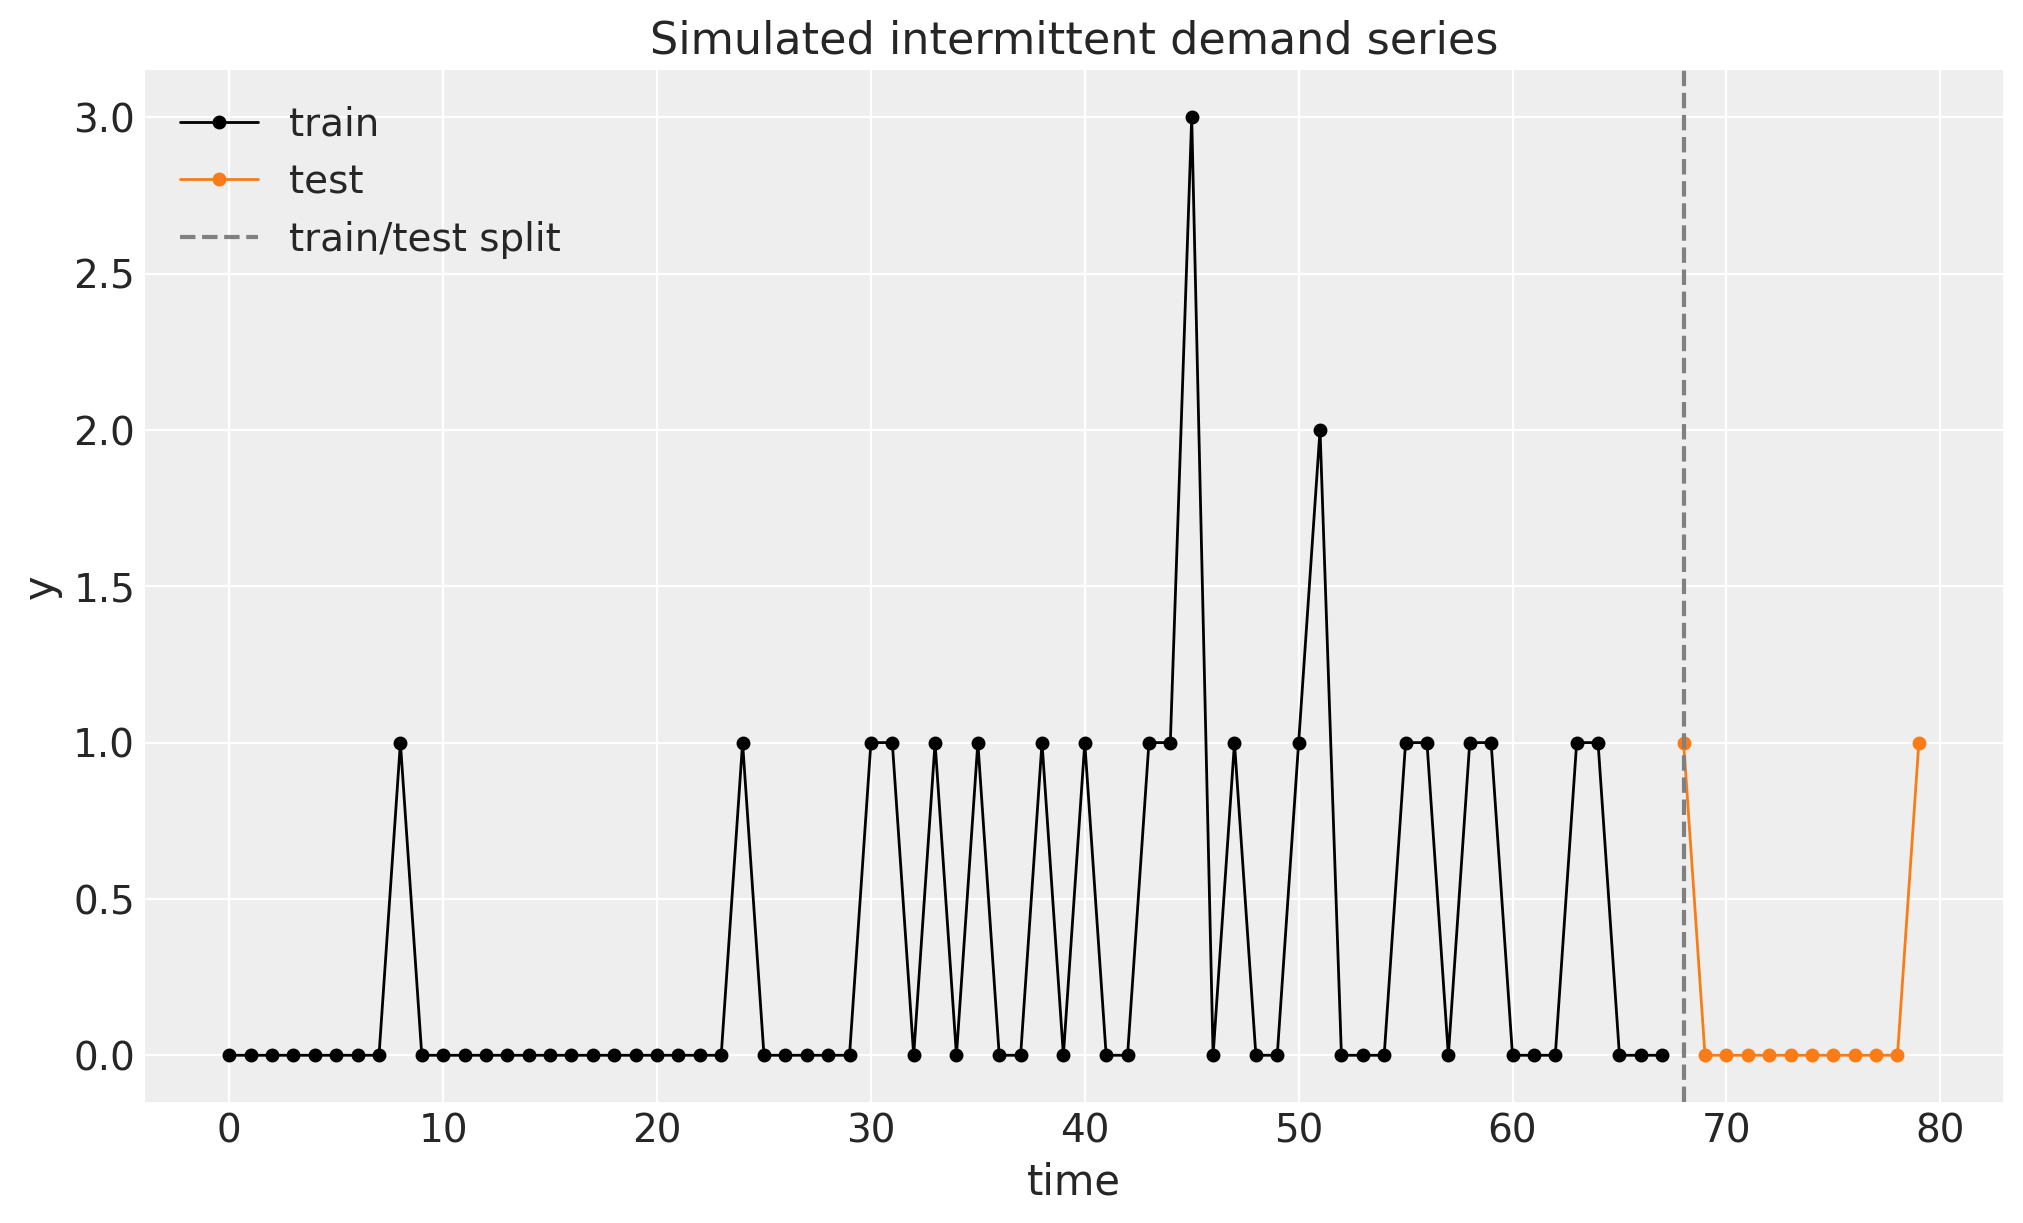

In [3]:
train_data = y_train[:, None]
test_data = y_test[:, None]
data_full = y[:, None]  # full series, used by the cross-validation at the end
covariates_train = train_data  # the demand history is the "covariate" of a Croston model
covariates_full = jnp.concatenate([y_train, jnp.zeros(n_test)])[:, None]
print(f"train data shape: {train_data.shape}, full covariates shape: {covariates_full.shape}")

fig, ax = plt.subplots()
ax.plot(t_train, y_train, "o-", color="black", lw=1, ms=4, label="train")
ax.plot(t_test, y_test, "o-", color="C1", lw=1, ms=4, label="test")
ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated intermittent demand series", xlabel="time", ylabel="y");

## Demand sizes and intervals

To see the raw material Croston's method works with, we derive the two component series from the training window: the demand sizes $z$ are the non-zero values in order of appearance, and the intervals $p$ are the gaps between consecutive demand times. Following the blog post's convention (`jnp.diff` with `prepend=-1`), the first interval counts from just before the start of the series, so a first demand at index $i$ has interval $i + 1$. Note that both series live on the *event* axis (one entry per demand event, not per period) and are much shorter than the original series.

The model below never uses these arrays directly: it recomputes the same information on the calendar axis inside the model body, which is what lets the cross-validation slice calendar time. This cell is exposition only.

demand events in train: 20 of 68 periods
demand sizes z: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 3. 1. 1. 2. 1. 1. 1. 1. 1. 1.]
demand intervals p: [ 9. 16.  6.  1.  2.  2.  3.  2.  3.  1.  1.  2.  3.  1.  4.  1.  2.  1.
  4.  1.]


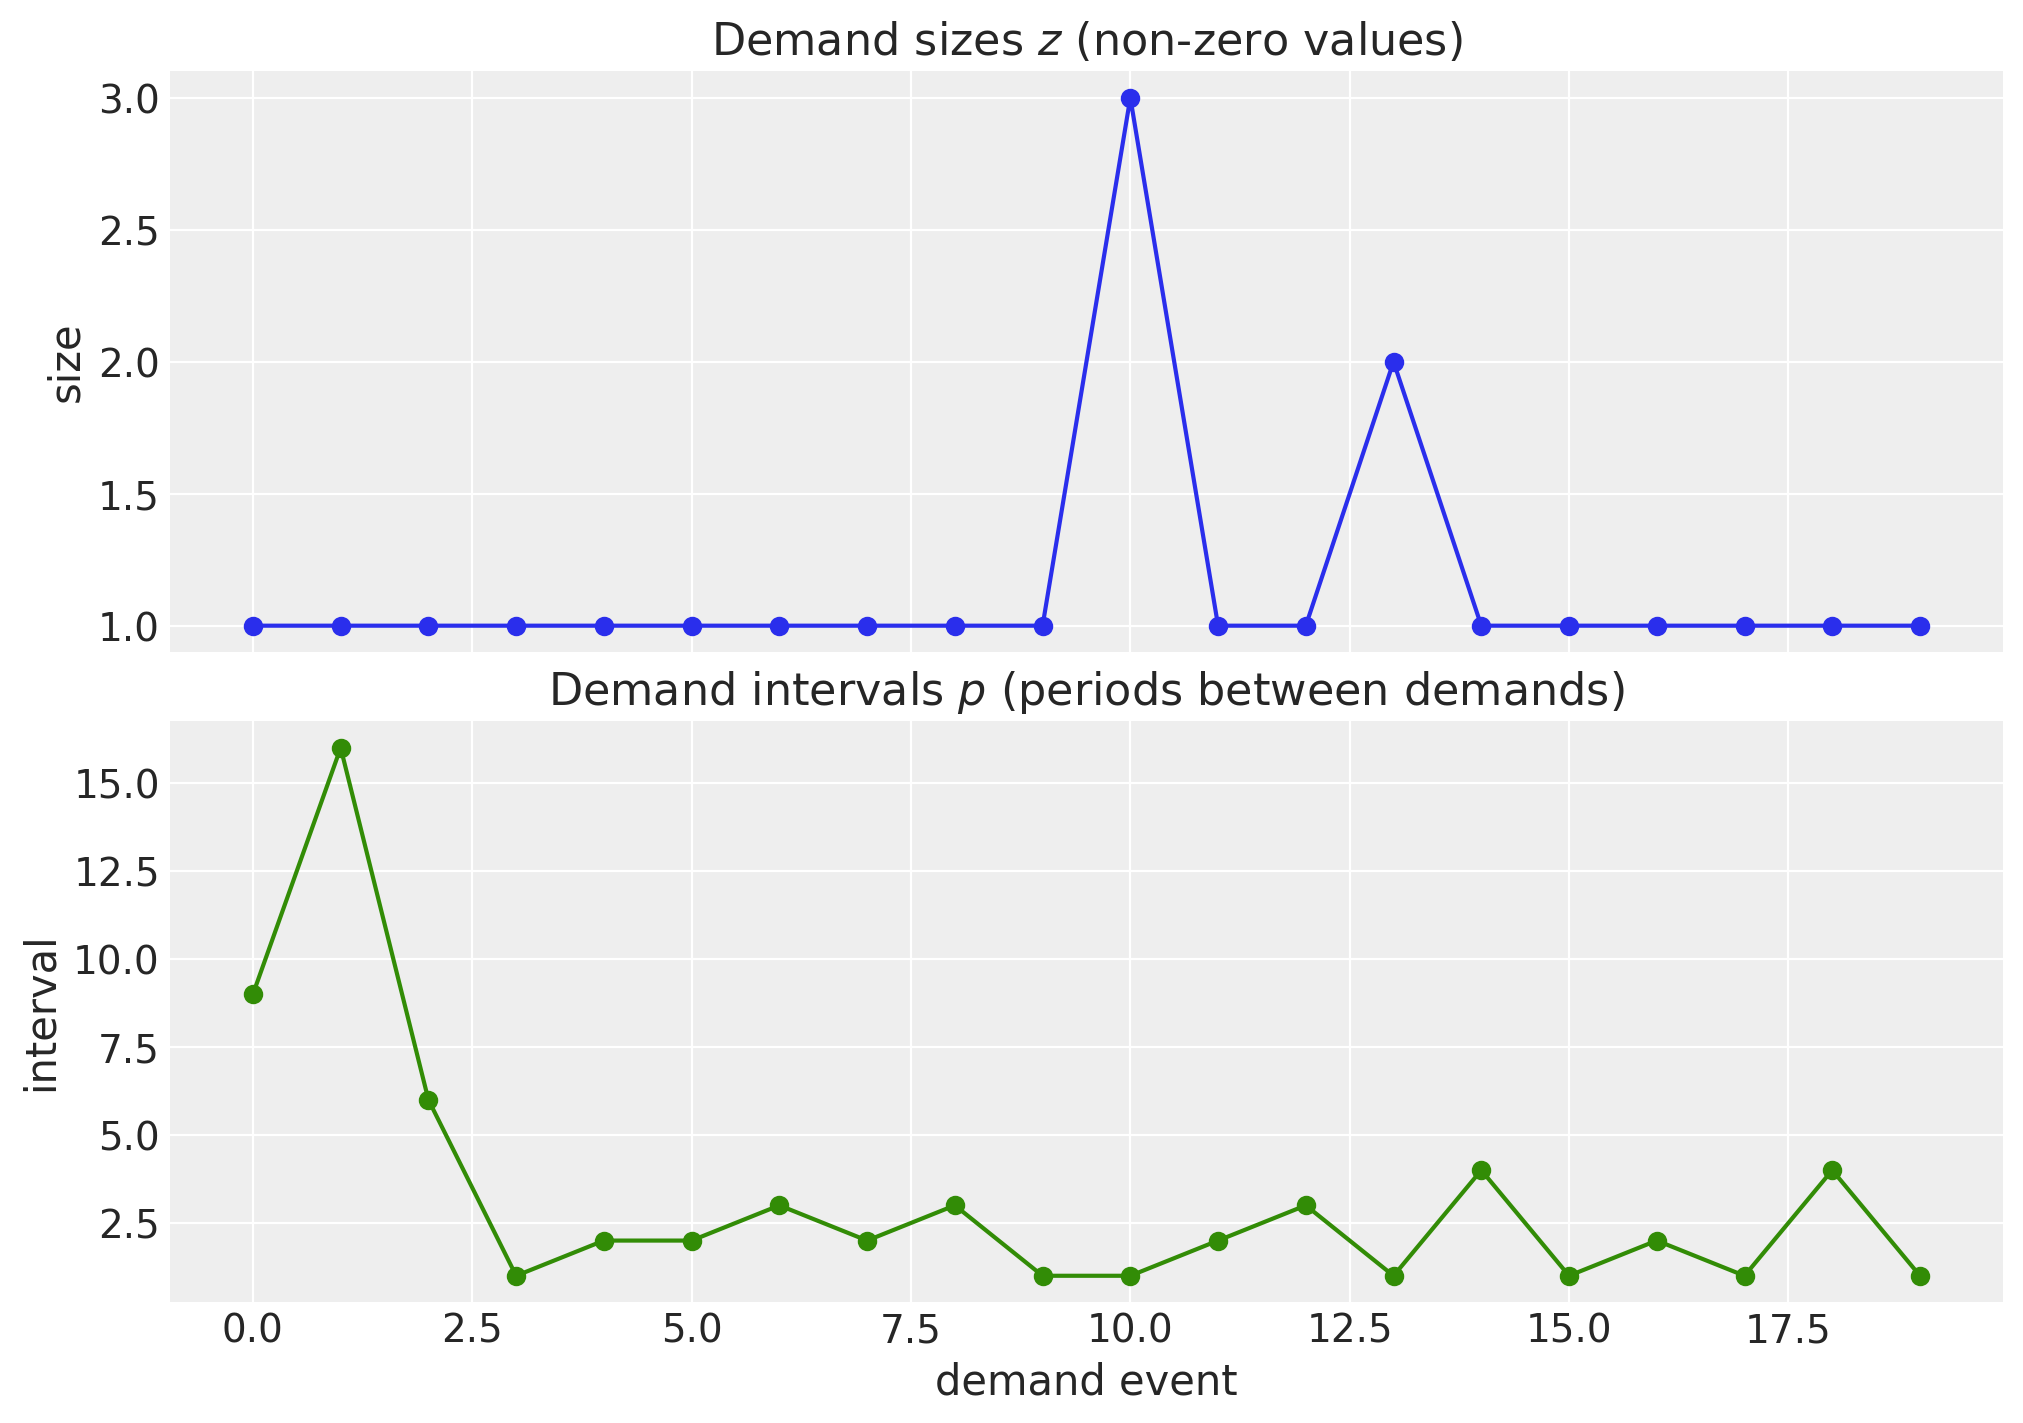

In [4]:
z = y_train[y_train != 0]
p_idx = jnp.flatnonzero(y_train)
p = jnp.diff(p_idx, prepend=-1).astype(jnp.float32)

print(f"demand events in train: {z.size} of {n_train} periods")
print(f"demand sizes z: {np.asarray(z)}")
print(f"demand intervals p: {np.asarray(p)}")

fig, (ax_z, ax_p) = plt.subplots(
    nrows=2, ncols=1, figsize=(10, 7), sharex=True, layout="constrained"
)
ax_z.plot(np.arange(z.size), np.asarray(z), "o-", color="C0")
ax_z.set(title="Demand sizes $z$ (non-zero values)", ylabel="size")
ax_p.plot(np.arange(p.size), np.asarray(p), "o-", color="C2")
ax_p.set(
    title="Demand intervals $p$ (periods between demands)",
    xlabel="demand event",
    ylabel="interval",
);

## Prior for the smoothing parameters

Both components get a $\text{Beta}(2, 20)$ prior on their smoothing parameter. Its mean is $2/22 \approx 0.09$ and most of its mass sits below $0.3$, consistent with the standard practice for Croston's method: the classical optimized implementations restrict the smoothing parameter to roughly $[0.1, 0.3]$, because a level that reacts strongly to each new demand produces volatile, over-reactive forecasts on sparse data. The prior concentrates on the same low-smoothing region while also keeping mass near zero, letting the data decide within it.

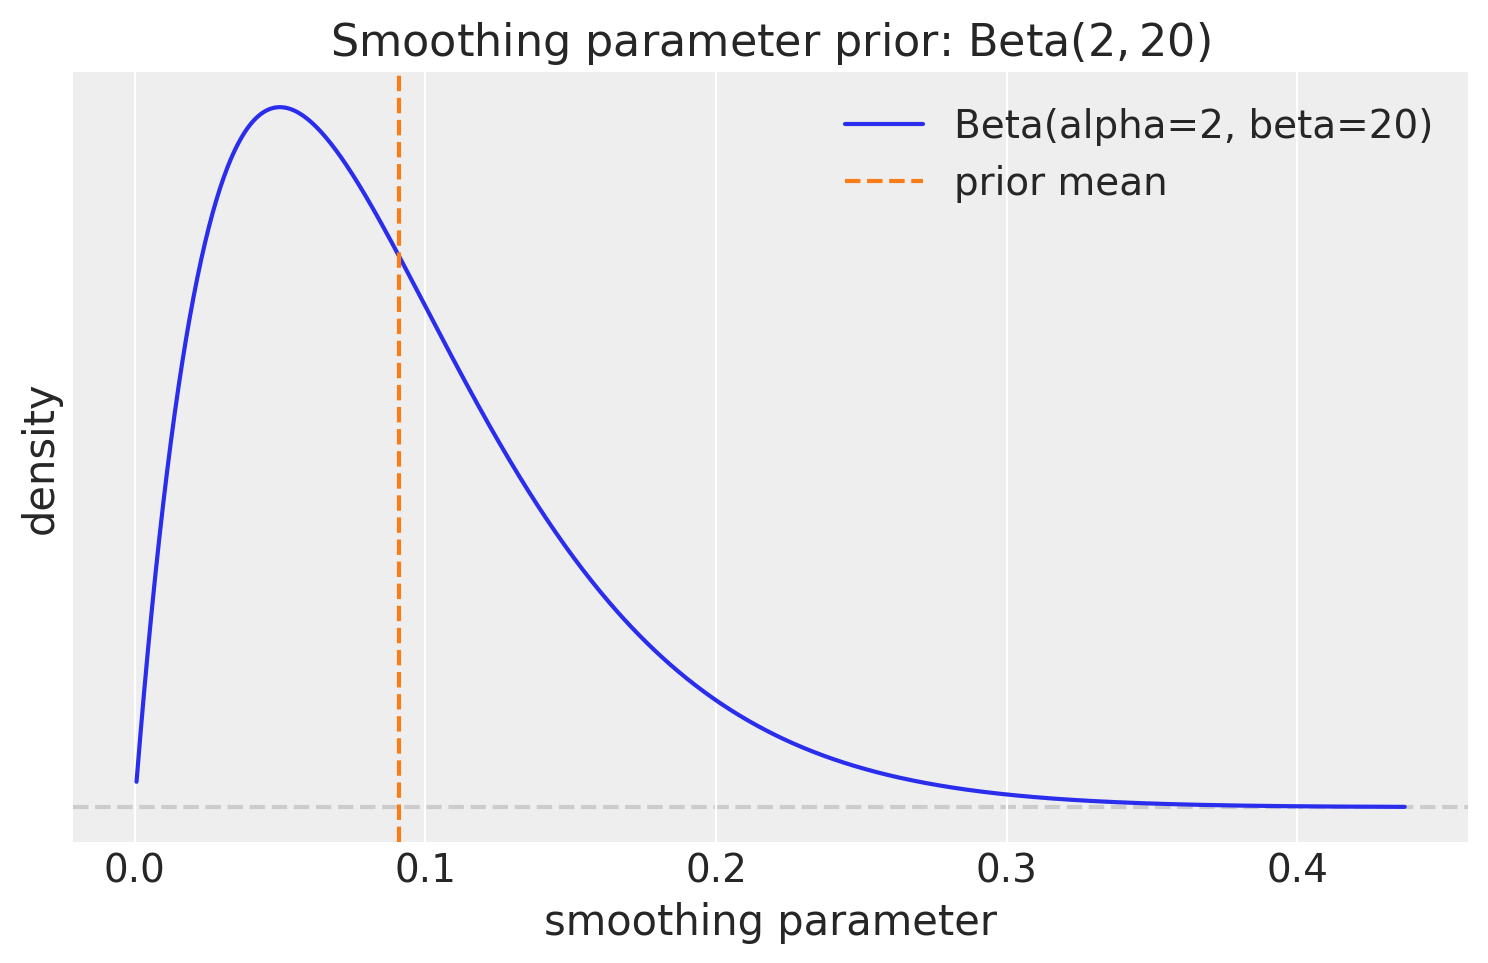

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
pz.Beta(2, 20).plot_pdf(ax=ax, color="C0")
ax.axvline(2 / 22, color="C1", ls="--", label="prior mean")
ax.legend()
ax.set(
    title=r"Smoothing parameter prior: $\text{Beta}(2, 20)$",
    xlabel="smoothing parameter",
    ylabel="density",
);

## Model specification

Croston's method runs **simple exponential smoothing** on each component. Writing $\ell_t$ for a component's level and $x_t$ for its observed value at a demand event, the level updates only when a demand occurs,

$$
\ell_t =
\begin{cases}
\alpha \, x_t + (1 - \alpha) \, \ell_{t-1} & \text{if } y_t > 0, \\
\ell_{t-1} & \text{otherwise},
\end{cases}
$$

and the likelihood at each demand event is the one-step-ahead prediction of the level model, $x_t \sim \text{Normal}(\ell_{t-1}, \sigma)$, exactly the level model of the blog's [exponential smoothing notes](https://juanitorduz.github.io/exponential_smoothing_numpyro/). We run two such recursions side by side: one for the demand sizes ($x_t = y_t$ at demand events) and one for the **inverse** intervals ($x_t = 1/p_t$). Modeling $1/p$ instead of $p$ is the blog post's numerical stability trick: the forecast then becomes a *product* of posterior samples, $\hat{y} = \hat{z} \cdot \widehat{1/p}$, instead of a quotient by samples that can sit close to zero.

The trick has a statistical cost worth naming. Smoothing $1/p$ estimates $\mathrm{E}[1/p]$, and by Jensen's inequality $\mathrm{E}[1/p] > 1/\mathrm{E}[p]$ whenever the intervals vary, so the fitted rate is biased *upward* relative to the true demand per period $\mathrm{E}[z]/\mathrm{E}[p]$. This is not specific to our Bayesian variant: the classical ratio $\hat{z}_t/\hat{p}_t$ suffers a related upward bias, analyzed by Syntetos and Boylan (2005), whose $(1 - \alpha/2)$ correction factor (the "SBA" estimator) is the standard remedy. We quantify the effect on our forecast below.

Each component gets its own priors,

\begin{align*}
\alpha & \sim \text{Beta}(2, 20), \\
\ell_0 & \sim \text{Normal}(0, 1), \\
\sigma & \sim \text{HalfNormal}(1).
\end{align*}

One transparency note on the priors: $\text{Normal}(0, 1)$ on the initial levels allows negative values for two quantities that are strictly positive (a demand size and an inverse interval). We keep the blog post's choice for comparability; centering the inits on the data or switching to positive priors is the natural refinement, in the same spirit as the truncated or log-normal component likelihoods mentioned in the forecast section.

Since both components run the *same* level model, we write it once and compose, exactly as the blog post does: there `croston_model` is built from two `level_model` calls wrapped in NumPyro's [`scope`](https://num.pyro.ai/en/stable/handlers.html#scope) handler, which prepends a prefix to every sample site inside the wrapped function so the two copies get distinct parameter names. We mirror that structure on the calendar axis with the package's [`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html) building block, whose job is precisely a recursion driven by the observed series: it takes the driving series, an initial carry, a `step` function returning the one-step-ahead mean and the carry update, and the innovation distribution, and it owns both the in-sample filter and the forecast scan. The reusable `level_channel` samples the three component priors (sites `smoothing`, `init`, and `noise`) and hands `ssoe` a `step` that emits the *pre-update* level (the one-step-ahead mean) and a `carry_fn` that applies the gated update above. The gate travels as an `xs` input, padded with zeros over the forecast horizon by [`pad_future`](https://juanitorduz.github.io/numpyro_forecast/reference/arrays.pad_future.html): with the gate off, the level is frozen there, so the forecast is the final level plus the component's iid innovation noise at every horizon step, which is exactly the level model's flat forecast distribution $\text{Normal}(\ell_T, \sigma)$. Padding the gate ourselves also matters for the cross-validation below, where `backtest` hands the model real future rows of the series that must not update the levels. Rows carry the observation axis, so the scalar level is `init[None]`. Calling the helper under `scope(level_channel, "z", divider="_")` and `scope(level_channel, "p_inv", divider="_")` yields the parameter names `z_smoothing`, `z_init`, ..., and the innovation sites `z_eps_future` and `p_inv_eps_future` that the block registers only when forecasting.

The `croston` body then only does what is specific to Croston's method:

1. **Bookkeeping.** From the observed prefix of the covariates it computes the demand indicator and, with a cumulative maximum over the last-seen demand index, the interval since the previous demand at every period. Both are fixed-shape computations, so they compile under `jax.lax.scan` and NUTS.
2. **In sample.** The likelihood is registered as two **masked** observation sites built from the channels' one-step-ahead means (`r.mu`), so only demand events contribute (masked periods add exactly zero log-density and zero gradient): the site `"obs"` carries the demand-size likelihood against the raw series, and `"obs_intervals"` the inverse-interval likelihood. The deterministic site `"rate"` exposes the running Croston fitted rate $\ell^z_{t-1} \cdot \ell^{1/p}_{t-1}$ for the in-sample plot.
3. **Out of sample.** When `h.future > 0` each channel's block draws its innovations at the `z_eps_future` and `p_inv_eps_future` sites and rolls its (frozen) level forward, returning the sampled future values as `r.y_future`; the body exposes them as `"z_forecast"` and `"p_inv_forecast"`, their product as the `"forecast"` site the package's `forecast` driver reads, and the product of the frozen levels as `"rate_future"`. Because the innovation sites do not exist while training, `Predictive` draws them from the prior at forecast time, the package's standard `_future` pattern. Croston's forecast is *flat* by construction: without new observations the levels never move, so every horizon step has the same predictive distribution, and `"rate_future"` makes that checkable.

In [6]:
def level_channel(h: Horizon, values: Array, gate: Array) -> tuple[SSOEResult, Array]:
    """Masked simple exponential smoothing level channel on the calendar axis.

    Samples the component priors (sites ``smoothing``, ``init``, ``noise``) and
    runs the gated level recursion through `ssoe()`, whose ``eps_future``
    innovation site provides the flat forecast predictive. Meant to be called
    under `numpyro.handlers.scope()`, which prefixes the site names per
    component.

    Parameters
    ----------
    h
        The train/forecast horizon for the current model call.
    values
        Observed component values on the calendar axis, shape ``(t_obs, 1)``;
        read only where ``gate`` is true.
    gate
        Boolean demand indicator on the calendar axis, shape ``(t_obs, 1)``; the
        level only updates where it is true, and never over the horizon.

    Returns
    -------
    tuple[SSOEResult, Array]
        The block result (one-step-ahead means, frozen forecast means, and the
        sampled future values) and the observation noise scale.
    """
    smoothing = numpyro.sample("smoothing", dist.Beta(concentration1=2, concentration0=20))
    # jnp.asarray only narrows numpyro's union return type for the type checker.
    init = jnp.asarray(numpyro.sample("init", dist.Normal(loc=0, scale=1)))
    noise = jnp.asarray(numpyro.sample("noise", dist.HalfNormal(scale=1)))

    def step(level, gate_t):
        # Emit the pre-update level (the one-step-ahead mean); update only at events.
        return level, lambda y_t, _: jnp.where(
            gate_t, smoothing * y_t + (1 - smoothing) * level, level
        )

    result = ssoe(
        h,
        "eps",
        values,
        init[None],
        step,
        dist.Normal(loc=0, scale=noise),
        xs=pad_future(gate, h.future),
    )
    return result, noise


def croston(covariates: Array, data: Array | None = None) -> None:
    """Croston's method as two scoped masked exponential smoothing level channels.

    Parameters
    ----------
    covariates
        The observed demand series itself, with time at axis ``-2``; only the
        first ``h.t_obs`` rows are read.
    data
        Observed demand with time at axis ``-2``, or ``None`` when the drivers
        sample the observation sites.
    """
    h = Horizon.from_data(covariates, data)
    y = covariates[..., : h.t_obs, :]  # observed history only; never reads beyond t_obs
    is_demand = y > 0

    # Interval since the previous demand at every period: cumulative max of the
    # last-seen demand index, shifted one step so it is strictly "before t".
    idx = jnp.arange(h.t_obs)[:, None]
    last_at_or_before = jax.lax.cummax(jnp.where(is_demand, idx, -1), axis=0)
    last_before = jnp.concatenate([jnp.full((1, 1), -1), last_at_or_before[:-1]])
    p_inv_obs = 1.0 / (idx - last_before).astype(y.dtype)

    z, z_noise = scope(level_channel, "z", divider="_")(h, y, is_demand)
    p_inv, p_inv_noise = scope(level_channel, "p_inv", divider="_")(h, p_inv_obs, is_demand)

    numpyro.deterministic("rate", z.mu * p_inv.mu)
    numpyro.sample("obs", dist.Normal(loc=z.mu, scale=z_noise).mask(is_demand), obs=h.data)
    numpyro.sample(
        "obs_intervals",
        dist.Normal(loc=p_inv.mu, scale=p_inv_noise).mask(is_demand),
        obs=p_inv_obs,
    )

    if h.future > 0:
        numpyro.deterministic("rate_future", z.mu_future * p_inv.mu_future)
        numpyro.deterministic("z_forecast", z.y_future)
        numpyro.deterministic("p_inv_forecast", p_inv.y_future)
        numpyro.deterministic("forecast", z.y_future * p_inv.y_future)

## Inference with NUTS

We fit the model on the training window with plain NumPyro: the No-U-Turn Sampler through `MCMC`, running $4$ chains of $1{,}000$ warmup and $1{,}000$ sampling steps each. The posterior has just six scalar parameters, three per component. The small `fit_nuts` helper wraps the call, because the cross-validation below refits the sampler on every fold with the same settings; `mcmc.get_samples()` returns the draws as a plain dictionary with the chains flattened together, the format every package driver consumes.

We then export the draws into an ArviZ-schema `xarray.DataTree` with [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html), which restores the `(chain, draw)` structure (we pass `num_chains=4`). Because we pass the *extended* covariates, which reach `n_test` steps past the data, the tree automatically carries `predictions` groups with the out-of-sample forecast draws next to the posterior, the in-sample posterior predictive, and the observed data.

In [7]:
def fit_nuts(
    rng_key: Array, model: ForecastModel, data: Array, covariates: Array
) -> dict[str, Array]:
    """Fit ``model`` with NUTS (4 chains, 1,000 warmup and 1,000 draws each) and return the draws."""
    mcmc = MCMC(
        NUTS(model),
        num_warmup=1_000,
        num_samples=1_000,
        num_chains=4,
        chain_method="sequential",
        progress_bar=False,
    )
    mcmc.run(rng_key, covariates, data)
    return mcmc.get_samples()


rng_key, rng_subkey = random.split(rng_key)
posterior = fit_nuts(rng_subkey, croston, train_data, covariates_train)

rng_key, rng_subkey = random.split(rng_key)
tree = to_datatree(
    rng_subkey,
    croston,
    posterior,
    train_data,
    covariates_full,
    num_chains=4,
    posterior_dims={"rate": ["time", "obs_dim"]},
)
tree

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:          (chain: 4, draw: 1000, time: 68, obs_dim: 1)
│       Coordinates:
│         * chain            (chain) int64 32B 0 1 2 3
│         * draw             (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│         * time             (time) int64 544B 0 1 2 3 4 5 6 7 ... 61 62 63 64 65 66 67
│         * obs_dim          (obs_dim) int64 8B 0
│       Data variables:
│           p_inv_init       (chain, draw) float32 16kB 0.3968 0.5238 ... 0.6935 0.1668
│           p_inv_noise      (chain, draw) float32 16kB 0.3601 0.3621 ... 0.455 0.4824
│           p_inv_smoothing  (chain, draw) float32 16kB 0.03843 0.07998 ... 0.1539
│           rate             (chain, draw, time, obs_dim) float32 1MB 0.3456 ... 0.7844
│           z_init           (chain, draw) float32 16kB 0.8709 1.202 ... 1.126 1.271
│           z_noise          (chain, draw) float32 16kB 0.431 0.6101 ... 0.5139 0.6101
│           z_smoothing      (chain, draw) float32 16kB 0.0827 0.04026 ... 0.04315
│       Attributes:
│           created_at:                 2026-08-27T12:29:48.726862+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 68, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 544B 0 1 2 3 4 5 6 7 8 ... 59 60 61 62 63 64 65 66 67
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 1MB 0.3385 1.062 ... 1.935
│       Attributes:
│           created_at:                 2026-08-27T12:29:48.906985+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 68, obs_dim: 1)
│       Coordinates:
│         * time     (time) int64 544B 0 1 2 3 4 5 6 7 8 ... 59 60 61 62 63 64 65 66 67
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (time, obs_dim) float32 272B 0.0 0.0 0.0 0.0 ... 1.0 0.0 0.0 0.0
│       Attributes:
│           created_at:                 2026-08-27T12:29:48.907279+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /constant_data
│       Dimensions:        (time: 68, covariate_dim: 1)
│       Coordinates:
│         * time           (time) int64 544B 0 1 2 3 4 5 6 7 ... 60 61 62 63 64 65 66 67
│         * covariate_dim  (covariate_dim) int64 8B 0
│       Data variables:
│           covariates     (time, covariate_dim) float32 272B 0.0 0.0 0.0 ... 0.0 0.0
│       Attributes:
│           created_at:                 2026-08-27T12:29:48.907475+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /predictions
│       Dimensions:  (chain: 4, draw: 1000, time: 12, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 96B 68 69 70 71 72 73 74 75 76 77 78 79
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 192kB 0.1277 0.4071 ... 0.3087
│       Attributes:
│    

## Diagnostics

`az.summary` on the six scalar parameters gives the convergence picture in one call: posterior means and standard deviations, the $94\%$ HDIs, effective sample sizes, and $\hat{R}$.

In [8]:
scalar_vars = [
    "z_smoothing",
    "z_init",
    "z_noise",
    "p_inv_smoothing",
    "p_inv_init",
    "p_inv_noise",
]
az.summary(tree, var_names=scalar_vars, ci_kind="hdi", ci_prob=0.94)

,mean,sd,hdi94_lb,hdi94_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
z_smoothing,0.087,0.056,0.012,0.22,3357,2301,1.00,0.00091,0.00091
z_init,1.067,0.226,0.59,1.5,3100,2317,1.00,0.0042,0.0037
z_noise,0.536,0.091,0.39,0.74,4392,2770,1.00,0.0015,0.0014
p_inv_smoothing,0.098,0.059,0.013,0.23,3424,2219,1.00,0.00096,0.00074
p_inv_init,0.479,0.179,0.11,0.78,3072,2006,1.00,0.0033,0.0027
p_inv_noise,0.383,0.068,0.28,0.54,4154,2581,1.00,0.0012,0.0011


The chains mix well: the $\hat{R}$ values are essentially $1$ and the effective sample sizes are healthy. The two smoothing posteriors barely move from the $\text{Beta}(2, 20)$ prior (mean $\approx 0.09$), which is what we should expect: with only $20$ demand events, the data carries little information about how fast the levels should adapt, so the prior's "smooth slowly" preference dominates, exactly as intended. The parameters the data *does* pin down are the component-specific ones: the initial demand-size level concentrates near the typical demand size of about $1$, the initial inverse-interval level lands just below one half, and the two noise scales come out clearly different. So even under a shared prior the two components learn genuinely distinct level models, which is the point of the optimized variant. The trace plots confirm the picture.

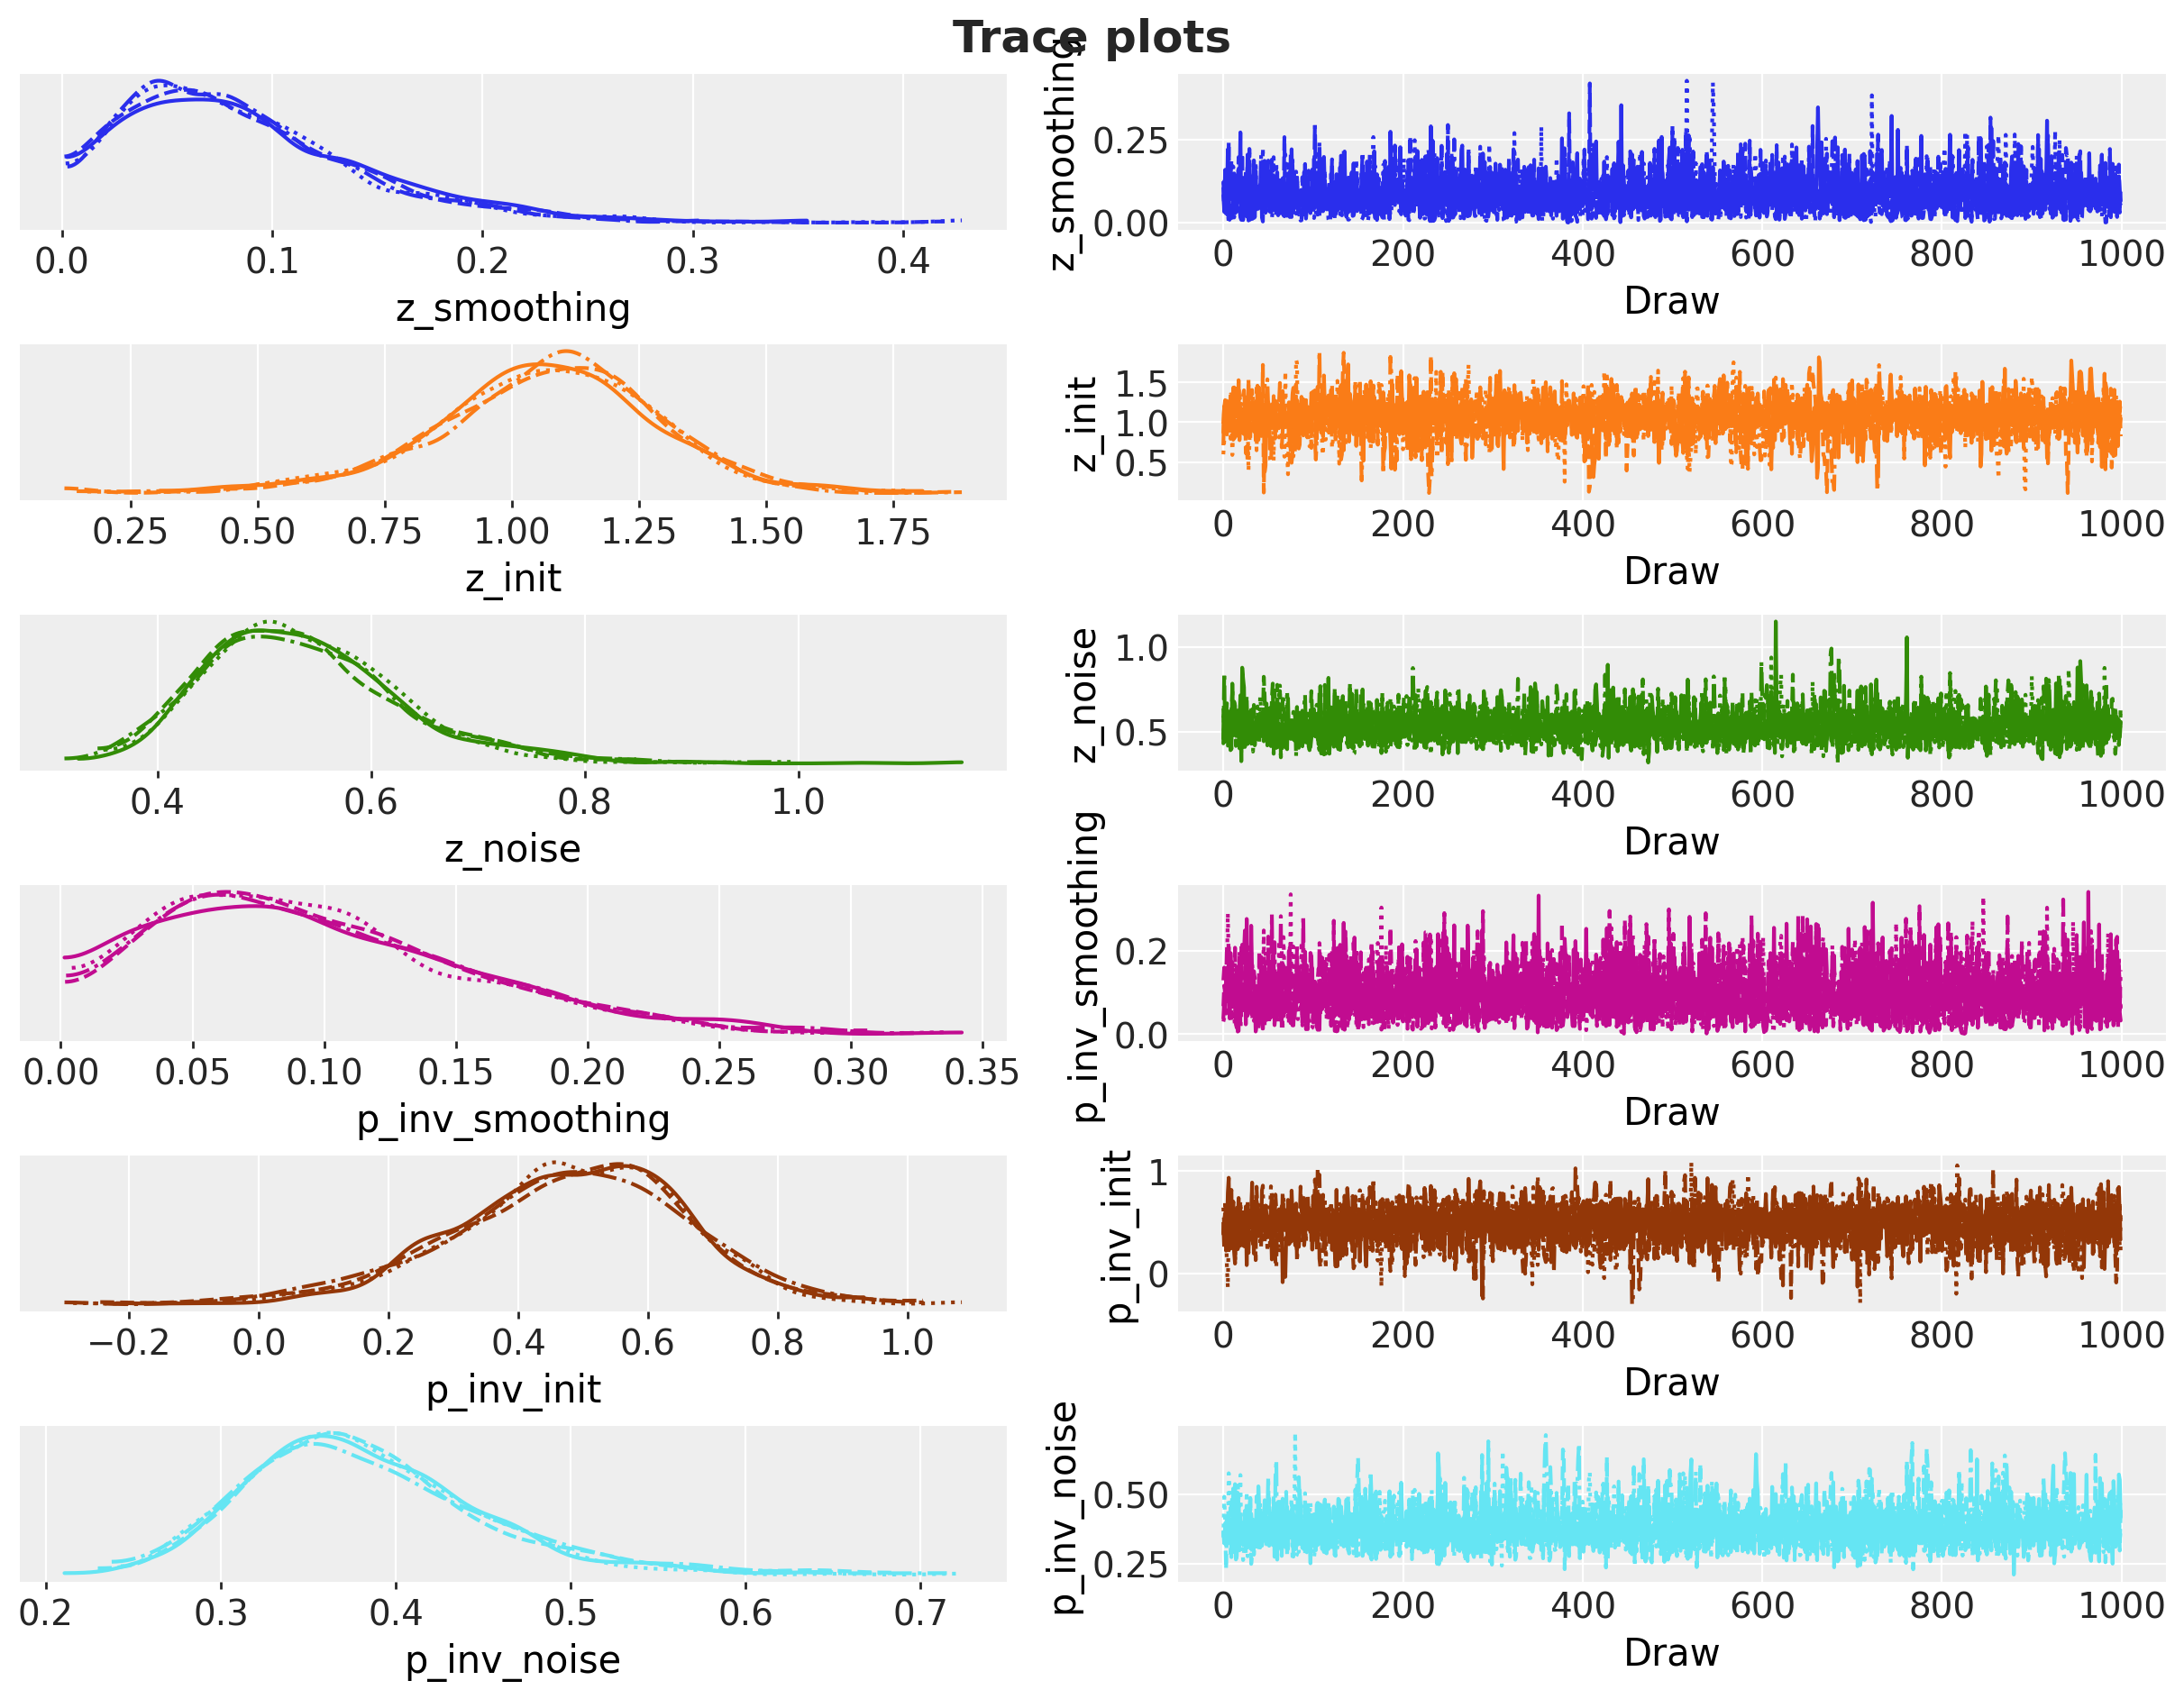

In [9]:
pc_trace = az.plot_trace_dist(
    tree,
    var_names=scalar_vars,
    compact=True,
    figure_kwargs={"figsize": (12, 9)},
)
pc_trace.viz["figure"].item().suptitle(
    "Trace plots",
    fontsize=18,
    fontweight="bold",
    y=1.03,
);

## In-sample fit

For the in-sample story we plot the posterior of the deterministic `"rate"` site: the running Croston fitted rate $\ell^z_{t-1} \cdot \ell^{1/p}_{t-1}$, the expected demand per period given the history so far. This is the quantity Croston's method actually tracks, and the plot shows it doing exactly what it should: it starts uncertain and near the prior, then climbs as demands arrive more and more frequently in the second half of the training window, because exponential smoothing weights the recent inter-demand intervals most heavily. Per the bias note in the model section, the level of the fitted rate should also be read as somewhat optimistic: smoothing the inverse intervals inflates it relative to the underlying demand frequency, on top of the recency weighting. This cell also defines the small plotting helpers (`stacked_draws` and `plot_band_forecast`) shared by the remaining band plots, so the later plot cells contain only what is specific to each figure.

A caveat worth spelling out: the tree's `posterior_predictive` group (the `"obs"` site) is *not* comparable to the raw series here. Because `"obs"` carries the masked demand-size likelihood, its draws describe the size of a demand *given that one occurs*, at every period, so plotting them against the mostly-zero series would look wildly miscalibrated while being exactly what the model asserts. The same reasoning is why the cross-validation below scores only out-of-sample forecasts (`eval_train=False`).

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


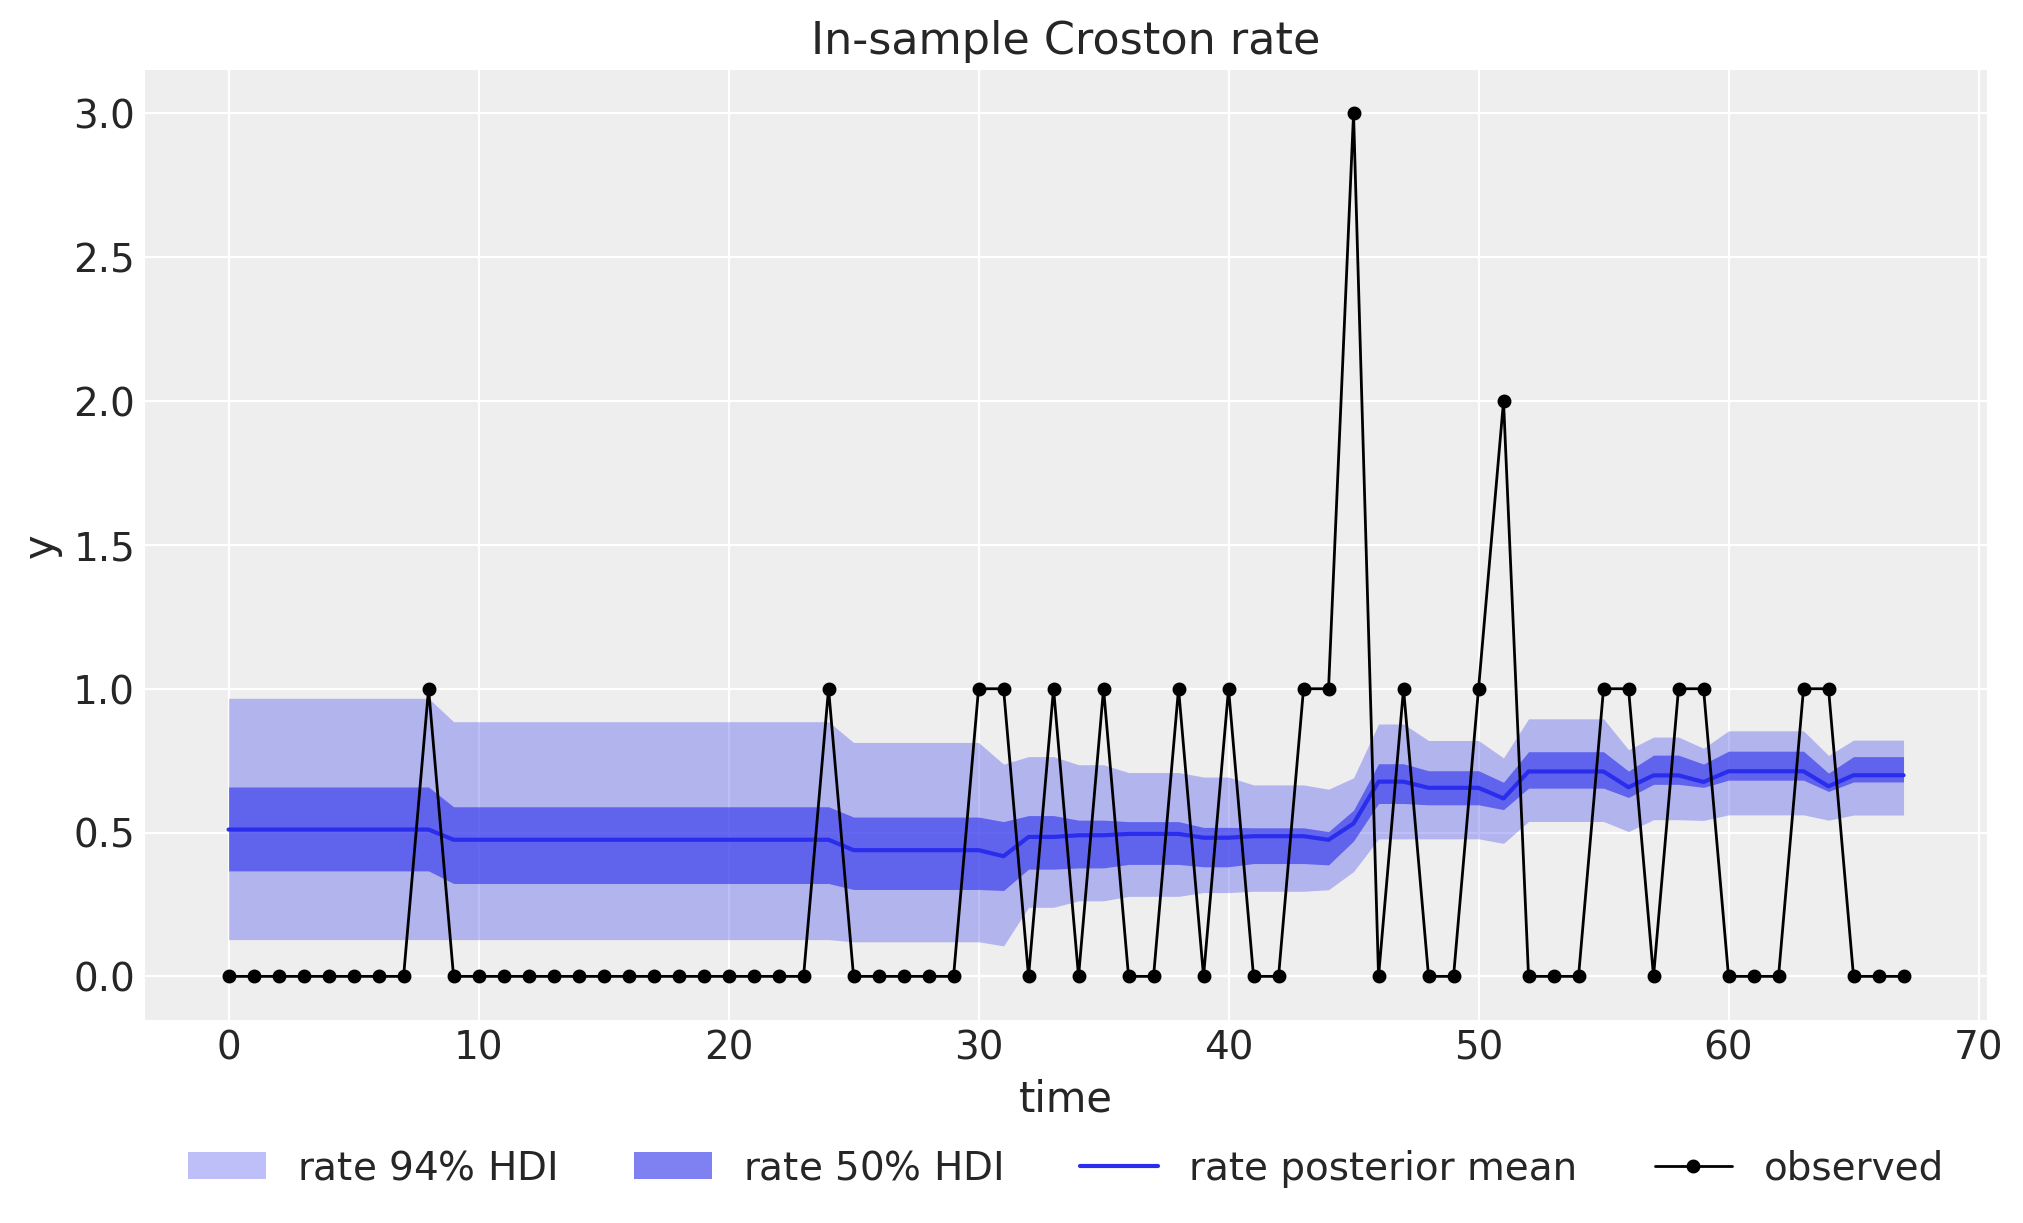

In [10]:
def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = [0.6, 0.3]  # 50% band darker, 94% band lighter


def stacked_draws(group: xr.DataTree | xr.DataArray, var: str) -> np.ndarray:
    """Stack a tree variable's ``(chain, draw)`` dims into a leading sample axis.

    Parameters
    ----------
    group
        A tree group holding ``var`` with dims ``(chain, draw, time, obs_dim)``
        (typed as the union ``tree[...]`` returns; a group always arrives here).
    var
        Name of the variable to extract.

    Returns
    -------
    np.ndarray
        The draws with shape ``(sample, time, obs_dim)``.
    """
    return (
        group.dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


def plot_band_forecast(
    draws: np.ndarray,
    x: np.ndarray,
    color: str,
    label_prefix: str = "",
    observed: Array | np.ndarray | None = None,
    figsize: tuple[float, float] = (12.0, 6.0),
) -> tuple[Axes, list[Artist]]:
    r"""Plot the posterior mean line and the $50\%$/$94\%$ HDI bands of ``draws``.

    Wraps ``predictions_to_datatree`` and ``az.plot_lm`` with the notebook-wide
    band styling (inner band darker via ``hdi_alphas``) and labels the artists.
    Overlays (observed series, split lines, extra point estimates) and the
    legend are the caller's responsibility.

    Parameters
    ----------
    draws
        Predictive draws with shape ``(sample, time, 1)``.
    x
        Numeric x values of length ``time``.
    color
        Matplotlib color for the bands and the mean line.
    label_prefix
        Prefix for the legend labels, e.g. ``"forecast "``.
    observed
        Optional observed data stored alongside the draws.
    figsize
        Figure size passed to ``plot_lm``.

    Returns
    -------
    tuple[Axes, list[Artist]]
        The axes and the labeled band and mean-line handles for the legend.
    """
    idata = predictions_to_datatree(draws, x, ["y"], observed=observed)
    pc = az.plot_lm(
        idata,
        y="obs",
        x="t",
        plot_dim="time",
        ci_kind="hdi",
        ci_prob=hdi_probs,
        smooth=False,
        point_estimate="mean",
        visuals={
            "ci_band": {"color": color},
            "observed_scatter": False,
            "pe_line": {"color": color, "alpha": 1.0, "width": 1.5},
        },
        aes={"alpha": ["prob"]},
        alpha=hdi_alphas,
        figure_kwargs={"figsize": figsize},
    )
    bands = pc.viz["ci_band"]["t"]
    band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
    band_94.set_label(hdi_label(0.94, prefix=label_prefix))
    band_50.set_label(hdi_label(0.5, prefix=label_prefix))
    pe_line = pc.viz["pe_line"]["t"].item()
    pe_line.set_label(f"{label_prefix}posterior mean")
    ax = pc.viz["figure"].item().axes[0]
    return ax, [band_94, band_50, pe_line]


rate_draws = stacked_draws(tree["posterior"], "rate")

ax, handles = plot_band_forecast(
    rate_draws,
    t_train.astype(float),
    "C0",
    label_prefix="rate ",
    observed=train_data,
    figsize=(10.0, 6.0),
)
(obs_line,) = ax.plot(
    t_train, np.asarray(y_train), "o-", color="black", lw=1, ms=4, label="observed"
)
ax.legend(
    handles=[*handles, obs_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
)
ax.set(title="In-sample Croston rate", xlabel="time", ylabel="y");

### Why do the HDI bands narrow over time?

Not because the parameter posterior tightens along the axis: the model is fit once on the whole training window, so the posterior is the same at every $t$. What is plotted is the posterior of the *deterministic* filtered rate, and the narrowing is a property of the filter. At $t = 0$ the rate is the product of the two initial levels, whose posteriors are wide (see the summary table above), so the band starts wide. Every demand event replaces a fraction $\alpha$ of a level with an observed value, so after $k$ demand events the initial level retains only a weight of $(1 - \alpha)^k$: the uncertainty inherited from `z_init` and `p_inv_init` decays away geometrically, which is why the band stays wide through the sparse first third of the series and tightens quickly once demands arrive frequently. At the same time the levels turn into exponentially weighted averages of *observed* values, which are fixed constants and, in this series, very regular (almost all demand sizes are $1$), so even the remaining uncertainty about the smoothing parameters barely moves them.

Two secondary features confirm this reading. Because the levels are frozen between demands, the band width is piecewise constant through runs of zeros: all the narrowing happens at demand events. And the band briefly *widens* again right after the unusual size-$3$ demand around $t = 45$, where the level's jump is $\alpha \, (3 - \ell)$, so uncertainty about the smoothing parameter translates into uncertainty about how far the level moved. Finally, keep in mind that this is the posterior of the mean rate with no observation noise, which is why it can get so tight; the forecast bands over the test window below are much wider because they add the component predictive noise $\text{Normal}(\ell_T, \sigma)$ on top of the parameter uncertainty.

## Forecast

The `predictions` group of the tree already holds the out-of-sample draws of the `"forecast"` site over the test window: the product of the two components' predictive samples. We plot the posterior mean and median together with the $50\%$ and $94\%$ HDI bands (inner band darker, outer lighter) against the held-out data, and score the forecast with the CRPS, a proper scoring rule that compares each observation to the whole predictive distribution (lower is better).

Two features of the plot deserve attention. First, the forecast is **flat**: without new observations the levels stay put, so Croston predicts the same demand rate for every future period. Second, the predictive distribution is **right-skewed**, so the mean sits visibly above the median; this asymmetry is information the Bayesian treatment gives us for free, where the classical implementations wrap a symmetric interval around a point forecast. The Normal component likelihoods do let a few draws go slightly negative (the same pragmatic choice as the blog post); truncated or log-normal component models are a natural exercise on top of this notebook.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


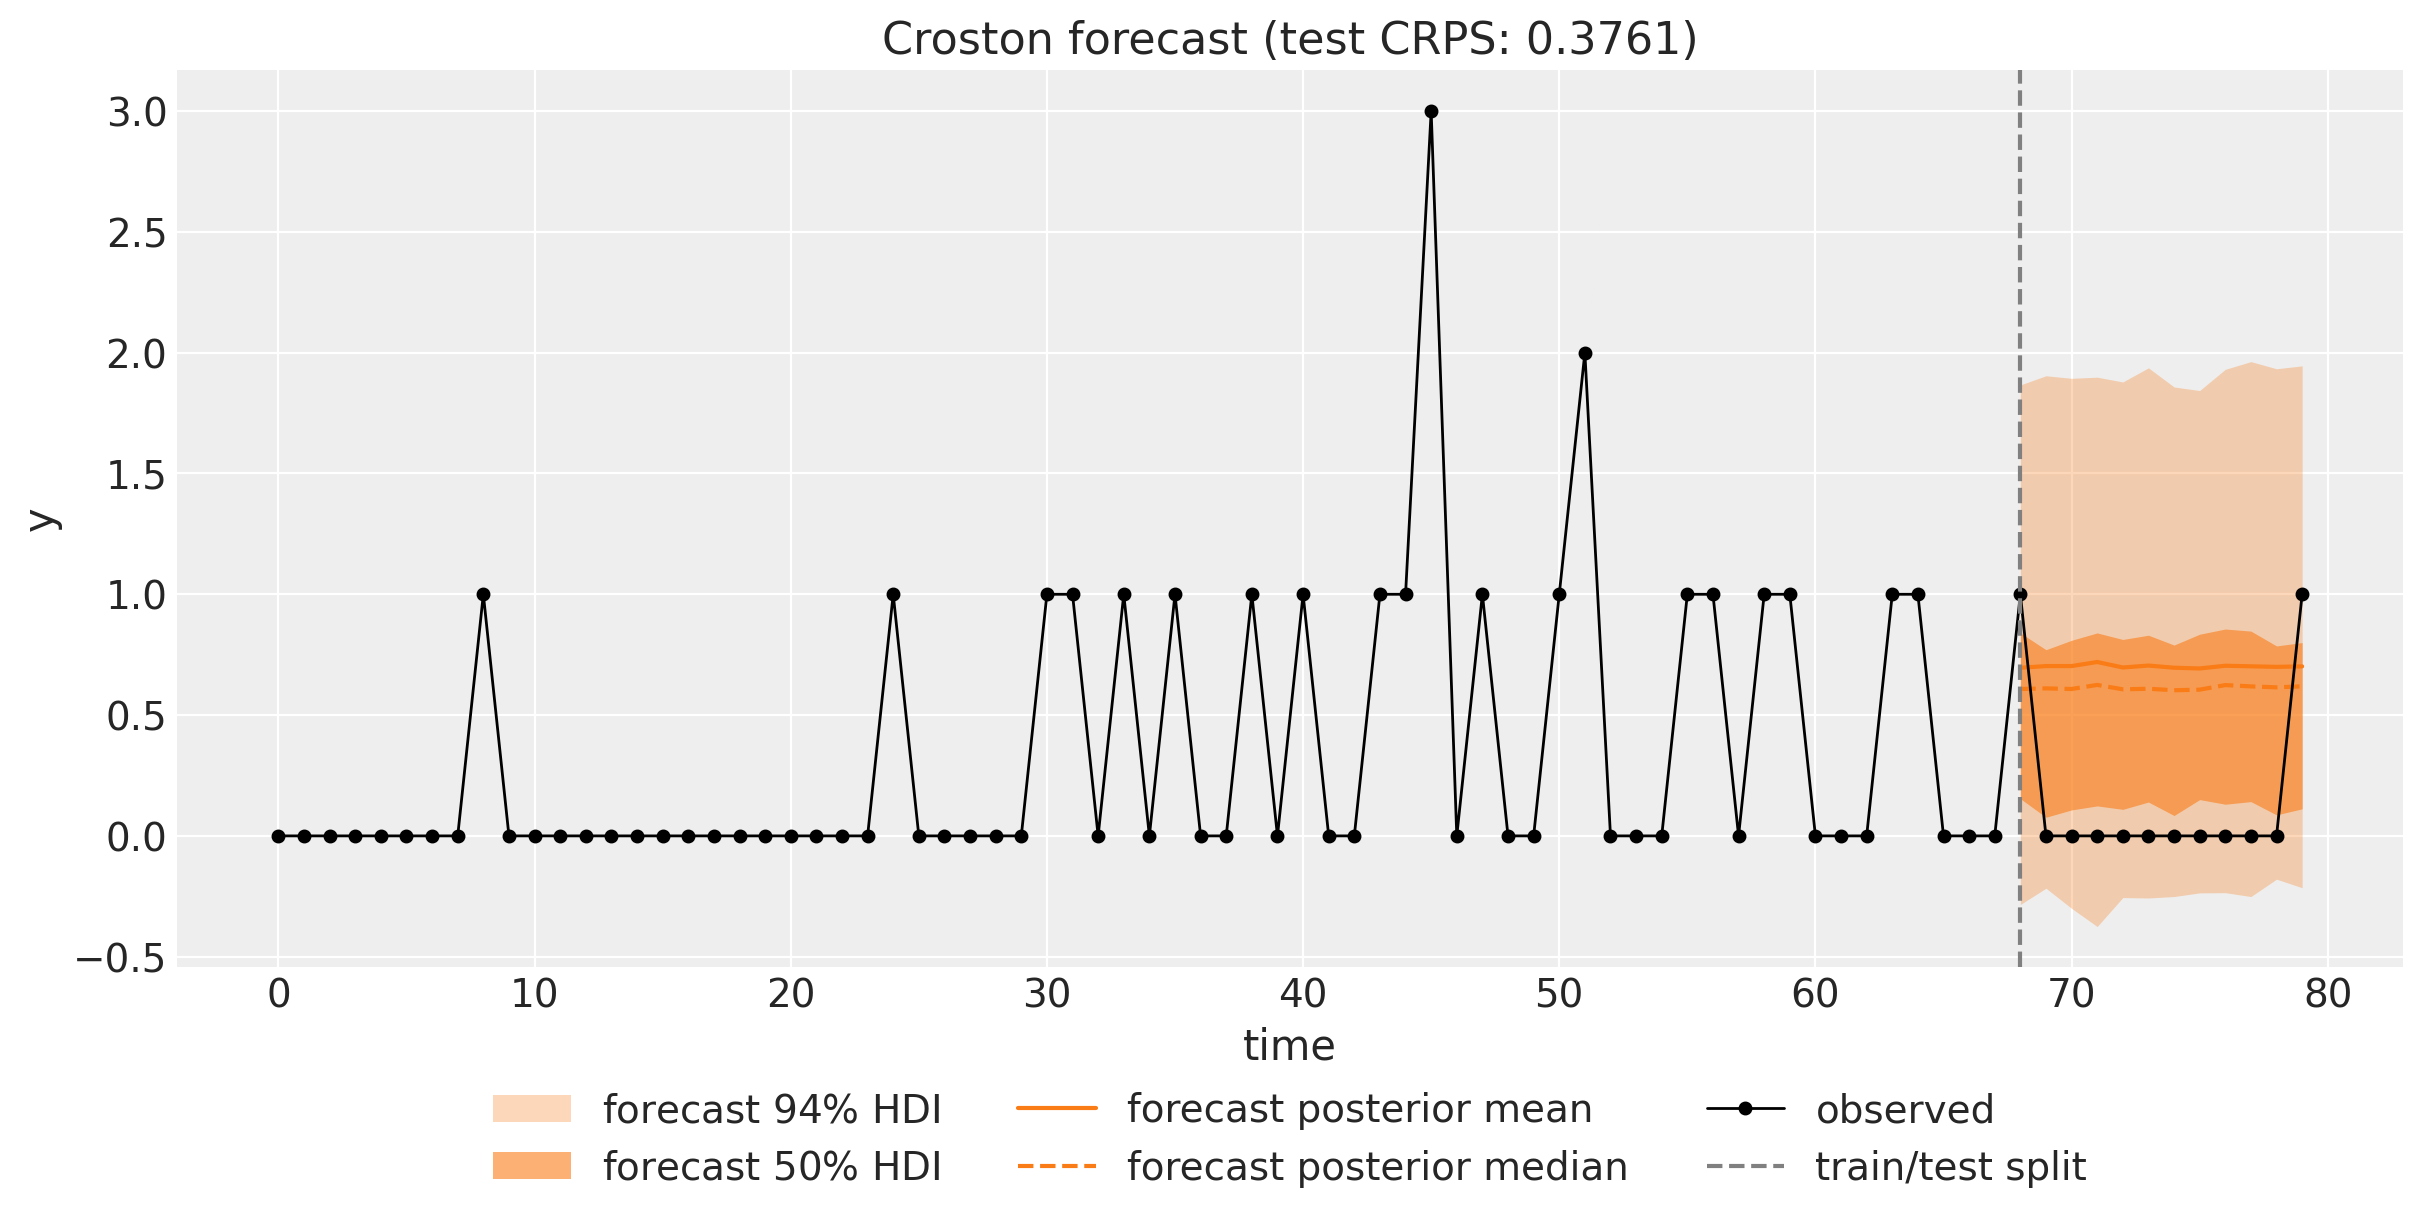

In [11]:
forecast_pp = stacked_draws(tree["predictions"], "obs")
crps_test = eval_crps(forecast_pp, test_data)

ax, handles = plot_band_forecast(
    forecast_pp, t_test.astype(float), "C1", label_prefix="forecast ", observed=test_data
)
(median_line,) = ax.plot(
    t_test,
    np.median(forecast_pp[..., 0], axis=0),
    color="C1",
    ls="--",
    lw=1.5,
    label="forecast posterior median",
)
(obs_line,) = ax.plot(t, np.asarray(y), "o-", color="black", lw=1, ms=4, label="observed")
split_line = ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[*handles, median_line, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(
    title=f"Croston forecast (test CRPS: {crps_test:.4f})",
    xlabel="time",
    ylabel="y",
);

### The Syntetos-Boylan correction

We can quantify the inversion bias directly from the posterior. Syntetos and Boylan derived their correction for the classical point estimator: multiply the Croston rate by $(1 - \alpha_p/2)$, where $\alpha_p$ is the interval smoothing parameter. Applying the same factor *per posterior draw* of `p_inv_smoothing` gives an approximately de-biased version of our forecast (approximate, because the factor was derived for the classical estimator, not for this Bayesian variant). The cell below compares the posterior mean forecast rate, its SBA-corrected version, and the train-window mean demand per period. With the low posterior smoothing values the correction is small, and the corrected rate remains well above the marginal mean: the remaining gap combines the recency weighting (the end of the training window is genuinely demand-dense) with the residual Jensen bias of smoothing inverse intervals, which the first-order SBA factor does not fully remove.

In [12]:
alpha_p = tree["posterior"].dataset["p_inv_smoothing"].stack(sample=("chain", "draw")).to_numpy()
forecast_sba = forecast_pp * (1 - alpha_p[:, None, None] / 2)

print(f"posterior mean forecast rate:        {forecast_pp.mean():.3f}")
print(f"SBA-corrected mean forecast rate:    {forecast_sba.mean():.3f}")
print(f"train-window mean demand per period: {float(jnp.mean(y_train)):.3f}")

posterior mean forecast rate:        0.702
SBA-corrected mean forecast rate:    0.666
train-window mean demand per period: 0.338


### Component forecasts

To see where the combined forecast comes from, we sample the two component predictives directly with `Predictive`, handing it the posterior draws and requesting the `"z_forecast"` and `"p_inv_forecast"` deterministic sites, and plot them side by side with a single faceted `plot_lm` call (the package's `predictions_to_datatree` lays the draws out so that `plot_lm` facets one panel per series). The demand-size component predicts the size of the next demand; the inverse-interval component predicts how much of a demand event arrives per period. Their product is the forecast above.

/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


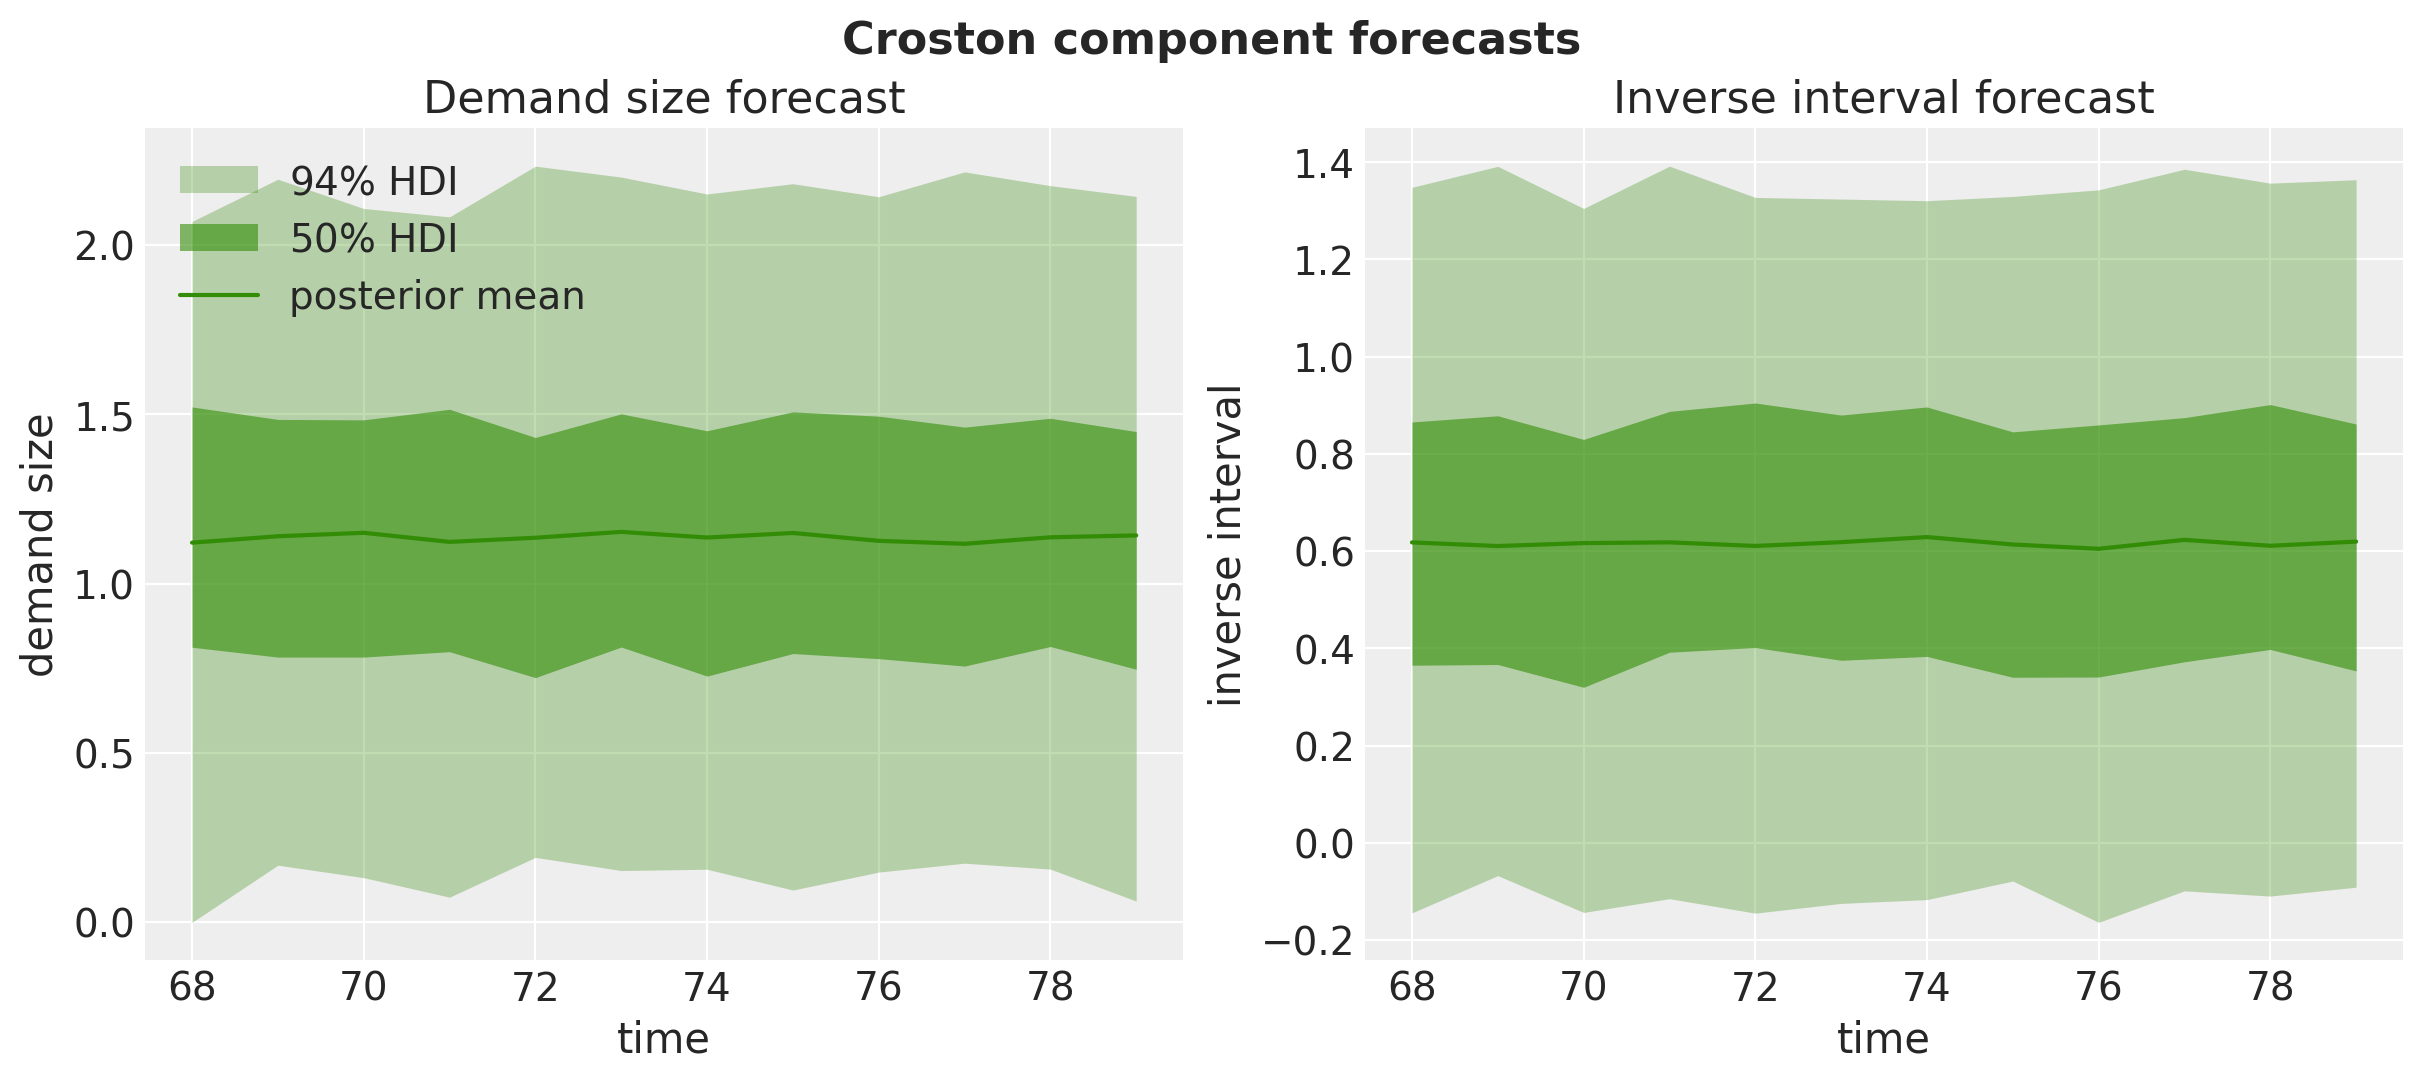

In [13]:
rng_key, rng_subkey = random.split(rng_key)
predictive = Predictive(
    croston,
    posterior_samples=posterior,
    return_sites=["z_forecast", "p_inv_forecast"],
)
component_draws = predictive(rng_subkey, covariates_full, train_data)
components = np.concatenate(
    [
        np.asarray(component_draws["z_forecast"]),
        np.asarray(component_draws["p_inv_forecast"]),
    ],
    axis=-1,
)

idata_components = predictions_to_datatree(
    components, t_test.astype(float), ["demand size", "inverse interval"]
)
pc = az.plot_lm(
    idata_components,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C2"},
        "observed_scatter": False,
        "pe_line": {"color": "C2", "alpha": 1.0, "width": 1.5},
    },
    aes={"alpha": ["prob"]},
    alpha=hdi_alphas,
    figure_kwargs={"figsize": (12, 5), "sharex": True},
)
axes = pc.viz["plot"]["t"]
axes.sel(series="demand size").item().set(
    title="Demand size forecast", xlabel="time", ylabel="demand size"
)
axes.sel(series="inverse interval").item().set(
    title="Inverse interval forecast", xlabel="time", ylabel="inverse interval"
)
bands = pc.viz["ci_band"]["t"]
band_94 = bands.sel(series="demand size", prob=0.94).item()
band_50 = bands.sel(series="demand size", prob=0.5).item()
band_94.set_label(hdi_label(0.94))
band_50.set_label(hdi_label(0.5))
pe_line = pc.viz["pe_line"]["t"].sel(series="demand size").item()
pe_line.set_label("posterior mean")
axes.sel(series="demand size").item().legend(handles=[band_94, band_50, pe_line], loc="upper left")
fig = pc.viz["figure"].item()
fig.suptitle("Croston component forecasts", fontsize=16, fontweight="bold", y=1.05);

## One-step-ahead cross-validation

A fixed-origin forecast tells us how the model does from one training window. The blog post's more interesting experiment is a **rolling-origin, one-step-ahead** evaluation: refit the model on an expanding training window and forecast a single step, repeatedly, across the whole test span. [`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html) runs this loop for us with `test_window=1` and `stride=1`; the fitting and forecasting inside each fold are delegated to a `forecast_fn` closure we write, which calls `fit_nuts` on the fold's training window and hands the draws to the package's [`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html) driver, so `backtest` itself has no opinion about the inference engine. With `min_train_window=n_train` the folds tile the test span exactly, one fold per held-out period, and `keep_predictions=True` retains each fold's forecast samples so we can assemble and plot them; `num_samples` records the ensemble size the closure returns, $4$ chains of $1{,}000$ draws. One subtlety worth knowing: `backtest` hands the closure the covariates over the *full* window, training rows followed by the held-out row, so the real future value is present in the array; the model reads only the first `t_obs` rows and freezes its gates over the horizon, which is what keeps every fold leak-free. Alongside the CRPS we track the empirical coverage of the central $50\%$ and $94\%$ intervals as per-fold indicators (with a single test point per fold, each is $0$ or $1$; we aggregate them across folds below).

In [14]:
def forecast_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and forecast the test horizon."""
    key_fit, key_fc = random.split(rng_key)
    fold_posterior = fit_nuts(key_fit, model, train_data, train_covariates)
    return forecast(
        key_fc, model, fold_posterior, train_data, full_covariates, batch_size=batch_size
    )


metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
results = backtest(
    rng_subkey,
    data_full,
    data_full,  # the series doubles as the covariates, sliced per fold by backtest
    lambda: croston,
    forecast_fn=forecast_fn,
    metrics=metrics,
    test_window=1,  # one-step-ahead forecasts
    stride=1,  # one fold per held-out period
    min_train_window=n_train,  # folds tile the test span exactly
    num_samples=4_000,  # 4 chains x 1,000 draws, what fit_nuts returns
    eval_train=False,  # in-sample "obs" scoring is not meaningful here (see above)
    keep_predictions=True,
)

split_points = [r.t1 for r in results]
test_crps = [r.metrics["crps"] for r in results]
print(f"folds: {len(results)} (split points: {split_points})")

folds: 12 (split points: [68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79])


### One-step-ahead forecasts

Because the folds tile the test span, we can concatenate the per-fold forecast samples into a single array of one-step-ahead predictive draws over the test window and plot them in one go.

The plot delivers the punchline of the blog post. Croston's forecast **barely moves while zeros accumulate**: the levels only update at demand events, so appending another zero changes nothing except the (unmodeled) age of the last demand, and the one-step-ahead bands stay flat through runs of zeros. Only when a non-zero demand arrives does the forecast shift, and with the low posterior smoothing parameters even that shift is small. This unresponsiveness to the *recency* of demand is Croston's well-known structural weakness, and it is precisely what the [TSB method](https://juanitorduz.github.io/tsb_numpyro/) fixes by smoothing a demand *probability* at every period instead of an interval at demand events only.

assembled one-step-ahead draws: (4000, 12, 1)


/Users/juanitorduz/Documents/numpyro_forecast/.venv/lib/python3.14/site-packages/arviz_plots/plots/lm_plot.py:360: UserWarning: When multiple credible intervals are plotted, it is recommended to map 'alpha' aesthetic to 'prob' dimension to differentiate between intervals.
  warnings.warn(


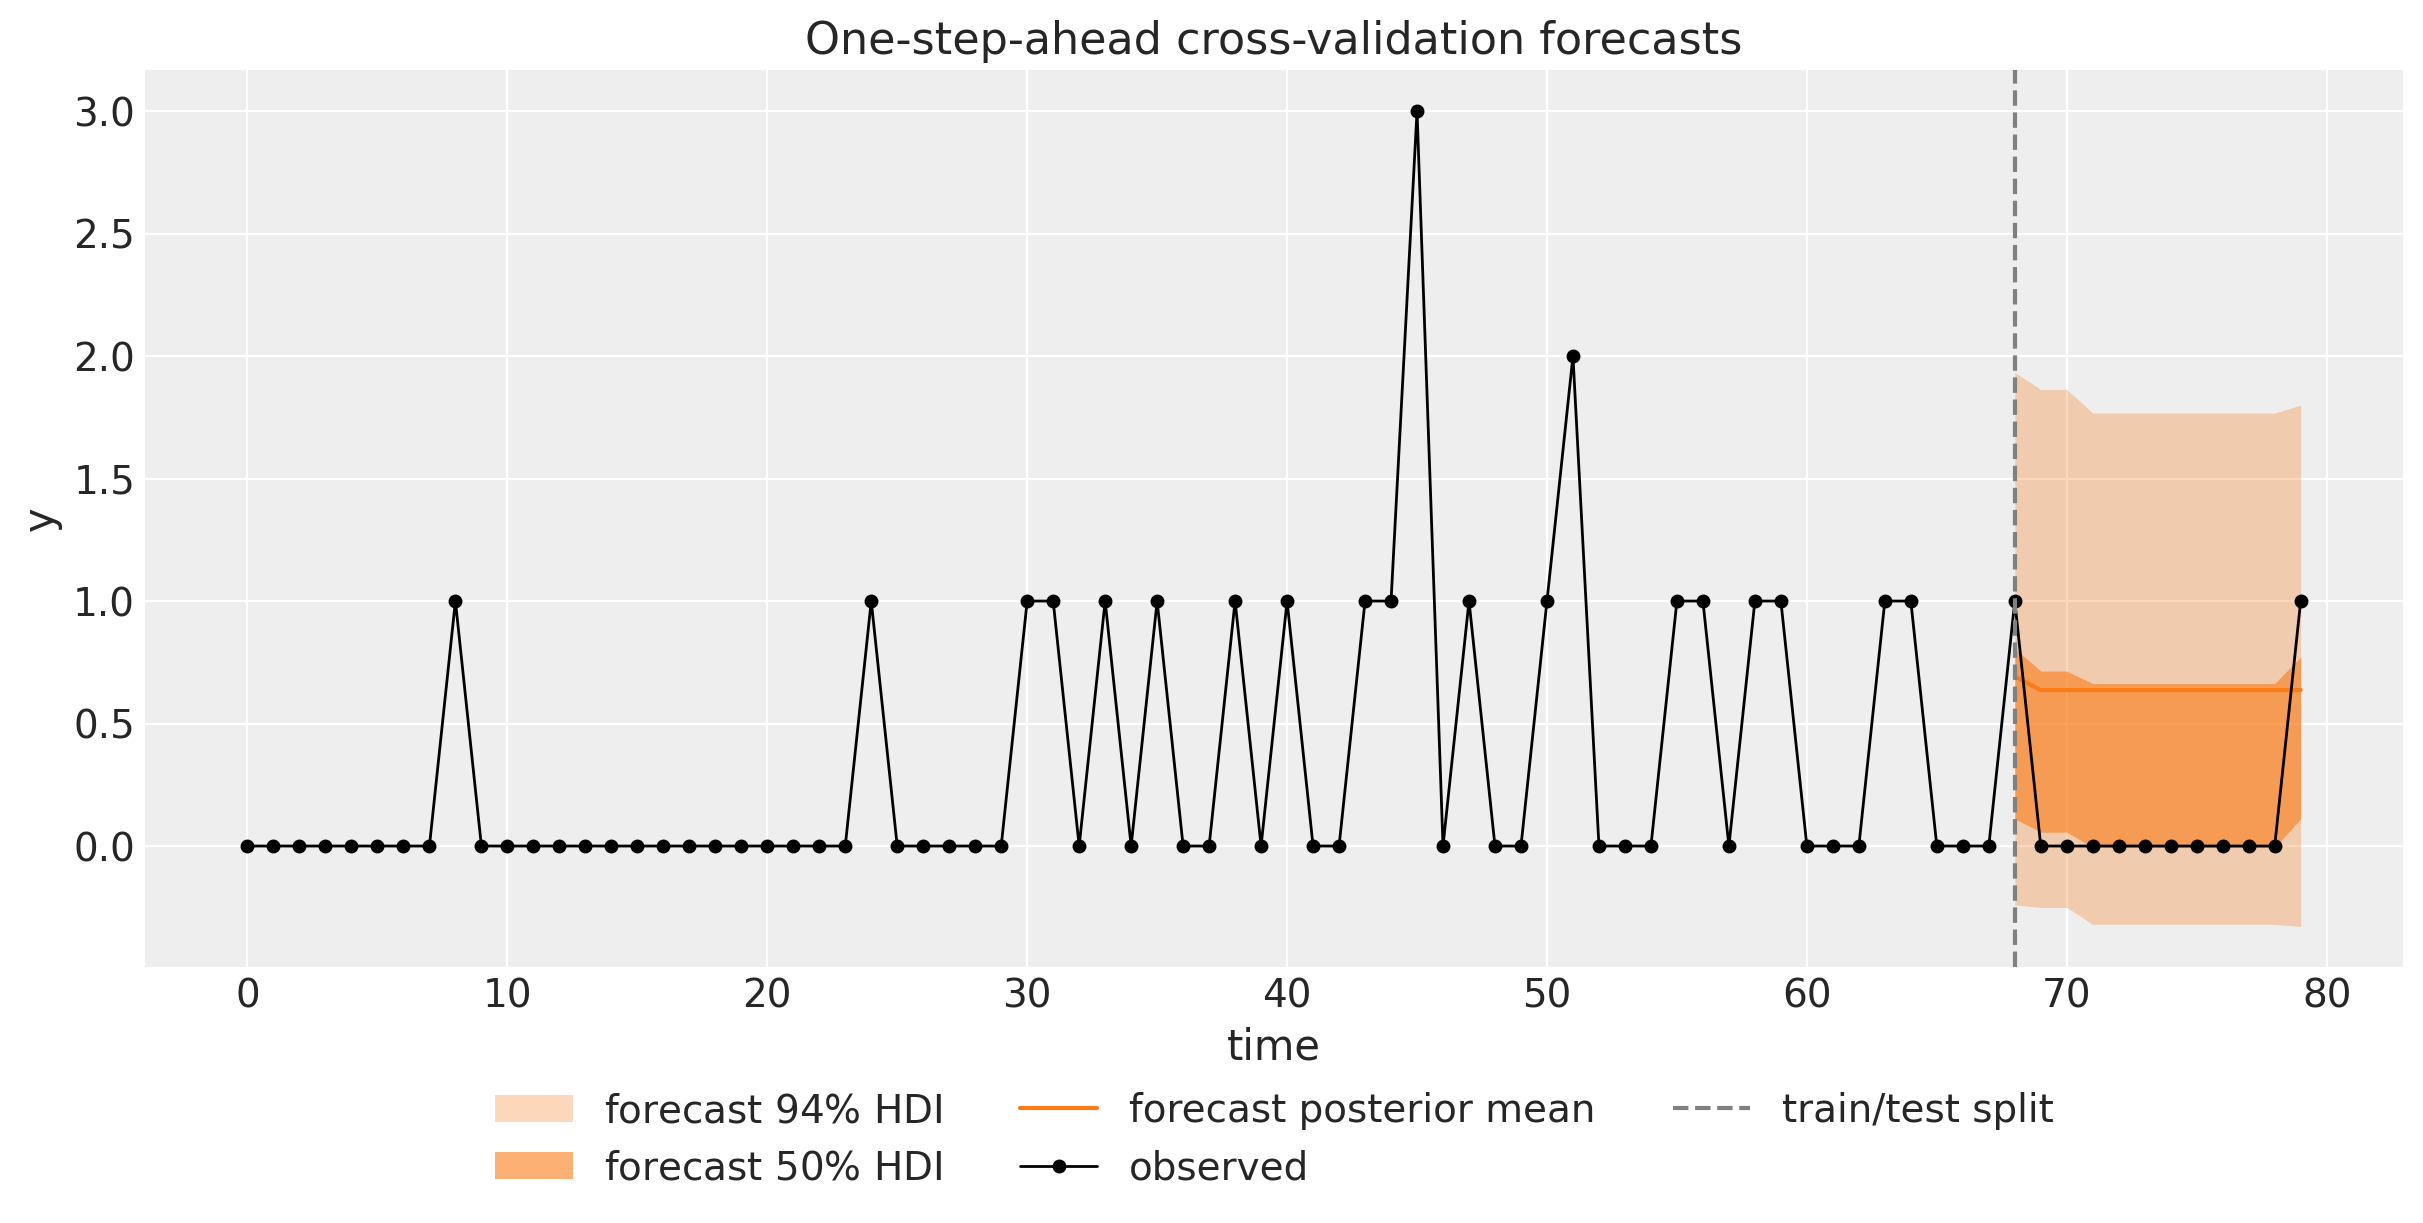

In [15]:
predictions = [r.prediction for r in results if r.prediction is not None]
cv_pred = np.concatenate([np.asarray(pred) for pred in predictions], axis=1)
print(f"assembled one-step-ahead draws: {cv_pred.shape}")

ax, handles = plot_band_forecast(
    cv_pred, t_test.astype(float), "C1", label_prefix="forecast ", observed=test_data
)
(obs_line,) = ax.plot(t, np.asarray(y), "o-", color="black", lw=1, ms=4, label="observed")
split_line = ax.axvline(n_train, color="gray", ls="--", label="train/test split")
ax.legend(
    handles=[*handles, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="One-step-ahead cross-validation forecasts", xlabel="time", ylabel="y");

### CRPS per fold

The per-fold CRPS makes the same point numerically: because the forecast barely changes from fold to fold, the score only moves when the *realization* does, and the plot is essentially two horizontal levels, one for the zero periods and one for the demand periods. The direction of the gap is worth a second look: the two demand periods score *better* than the zeros. After the demand-dense end of the training window the posterior rate sits closer to $1$ than to $0$, so a size-one demand is actually the cheaper outcome, while every zero pays the roughly constant price of a rate forecast that cannot switch itself off between demands.

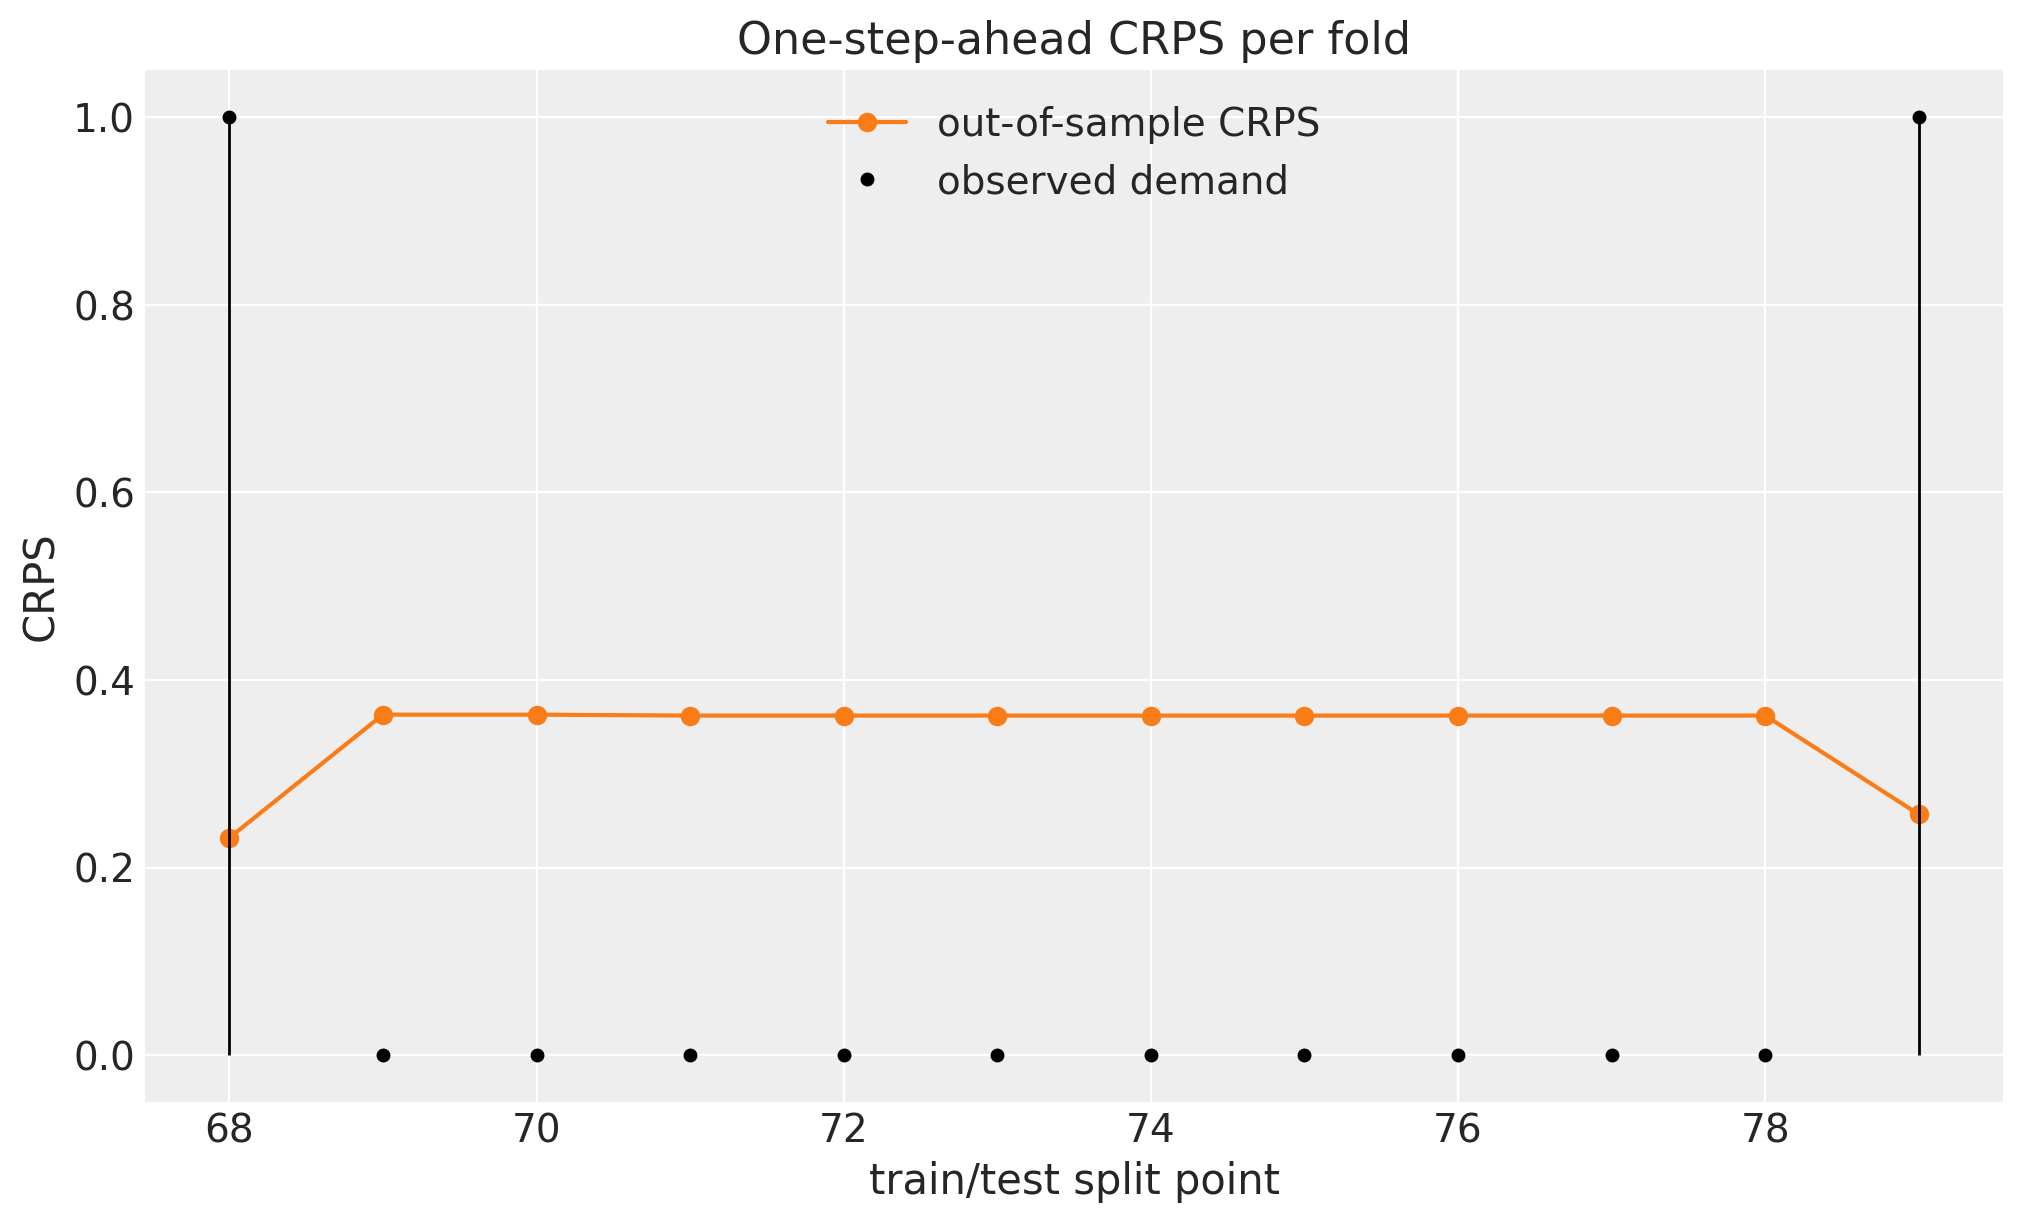

In [16]:
fig, ax = plt.subplots()
ax.plot(split_points, test_crps, "o-", color="C1", label="out-of-sample CRPS")
markerline, stemlines, baseline = ax.stem(t_test, np.asarray(y_test), basefmt=" ")
plt.setp(markerline, color="black", markersize=4, label="observed demand")
plt.setp(stemlines, color="black", linewidth=1)
ax.legend()
ax.set(
    xlabel="train/test split point",
    ylabel="CRPS",
    title="One-step-ahead CRPS per fold",
);

### Calibration

With a single observation per fold, per-fold coverage is a $0/1$ indicator, so instead of the ARMA example's per-fold coverage plot we aggregate: the empirical coverage across all folds (equivalently, the mean of the per-fold indicators) against the nominal levels, computed directly from the assembled draws with `eval_coverage`. We also compare the one-step-ahead CRPS with the fixed-origin CRPS from the forecast section.

One caveat, inherited from the ARMA example but sharper here: `eval_coverage` measures coverage of the *central quantile interval*, while the plotted bands are HDIs. For the ARMA example's near-symmetric predictive the two nearly coincide; for the right-skewed predictive here they genuinely differ, so these numbers check the calibration of central intervals rather than literally of the bands shown above.

In [17]:
cv_crps = eval_crps(cv_pred, test_data)
cov_50 = eval_coverage(cv_pred, test_data, alpha=0.5)
cov_94 = eval_coverage(cv_pred, test_data, alpha=0.94)

print(f"one-step-ahead CRPS over the test span: {cv_crps:.4f}")
print(f"fixed-origin CRPS over the test span:   {crps_test:.4f}")
print(f"empirical 50% coverage: {cov_50:.2f}  (nominal 0.50)")
print(f"empirical 94% coverage: {cov_94:.2f}  (nominal 0.94)")

one-step-ahead CRPS over the test span: 0.3427
fixed-origin CRPS over the test span:   0.3761
empirical 50% coverage: 0.08  (nominal 0.50)
empirical 94% coverage: 1.00  (nominal 0.94)


The numbers complete the picture, and they are instructive rather than flattering. Refitting at every step buys almost nothing over forecasting the whole span from a fixed origin, which is the punchline again in metric form: the new observations are mostly zeros, and zeros do not move a Croston forecast. The coverage is badly off nominal in an asymmetric way: the central $50\%$ interval of the rate forecast lies strictly above zero, so on a test span dominated by zeros it almost never covers, while the wide $94\%$ interval covers everything. This is not an inference failure but a structural mismatch: Croston's predictive describes the *demand rate per period*, not the count distribution of the individual periods, so per-period interval coverage on a zero-heavy series is poor by construction. A predictive that actually covers the observed counts needs an explicit per-period model of demand occurrence, which is precisely what the TSB method adds.

## References

- Orduz, J. [*Croston's Method for Intermittent Time Series Forecasting in NumPyro*](https://juanitorduz.github.io/croston_numpyro/). The blog post this notebook ports.
- Orduz, J. [*TSB Method for Intermittent Time Series Forecasting in NumPyro*](https://juanitorduz.github.io/tsb_numpyro/). The follow-up method that addresses Croston's unresponsiveness to demand recency.
- Orduz, J. [*Notes on Exponential Smoothing with NumPyro*](https://juanitorduz.github.io/exponential_smoothing_numpyro/). The predecessor post whose level model this notebook reuses.
- Croston, J. D. (1972). *Forecasting and stock control for intermittent demands*. Operational Research Quarterly, 23(3), 289-303.
- Syntetos, A. A., & Boylan, J. E. (2005). *The accuracy of intermittent demand estimates*. International Journal of Forecasting, 21(2), 303-314. The bias analysis behind the $(1 - \alpha/2)$ correction quantified above.
- Morgan, P. [*Croston's Method*](https://www.pmorgan.com.au/tutorials/crostons-method/). A succinct tutorial on the classical method.
- statsforecast documentation: [`CrostonOptimized`](https://nixtlaverse.nixtla.io/statsforecast/src/core/models.html#crostonoptimized), the classical baseline the blog post compares against.
- The [exponential smoothing example](https://juanitorduz.github.io/numpyro_forecast/examples/exponential_smoothing_state_space.html) in this documentation, which uses the same `ssoe` building block for the damped Holt-Winters state space model.
- The [ARMA example](https://juanitorduz.github.io/numpyro_forecast/examples/arma.html) in this documentation, which introduces the series-as-covariates pattern and the expanding-window `backtest` workflow.